# Project Overview

This project investigates whether machine learning can improve the accuracy of the classical SABR implied volatility approximation while preserving its computational efficiency.

The SABR model introduced by **Hagan et al. (2002)** provides a widely used closed-form approximation for implied volatility. While this formula is fast and practical, it can produce noticeable errors for long maturities or extreme strikes. More accurate approaches, such as **Antonov et al. (2013)**, improve pricing accuracy but are typically more computationally expensive.

Following **Funahashi (2023)**, this project explores whether an Artificial Neural Network (ANN) can learn the **approximation error** of the SABR formula. Instead of predicting option prices directly, the ANN is trained to estimate the difference between Monte Carlo implied volatility and the SABR approximation.

The workflow of this project is structured as follows:

1. **Pricing tools**
   Implement the Black model, Bachelier model, and the Hagan SABR implied volatility approximation.

2. **SABR Monte Carlo simulation**
   Generate benchmark option prices and implied volatilities under the SABR model.

3. **Approximation error analysis**
   Compare Monte Carlo implied volatilities with the SABR approximation.

4. **Neural network training**
   Train an ANN to learn the approximation error.

5. **Evaluation**
   Evaluate whether the corrected volatility
   [
   \sigma_{corrected} = \sigma_{Hagan} + \text{ANN prediction}
   ]
   improves accuracy while maintaining computational efficiency.


# Phase 1 — Pricing Tools & Validation

This notebook implements the three foundational pricing modules needed for the SABR + ANN project:

1. Black (log-normal) formula — standard implied vol quoting convention
2. Bachelier (normal) formula — for negative-rate scenarios
3. Hagan et al. (2002) SABR approximation — the baseline we aim to correct with ANN

These tools correspond to the pricing / implied-volatility representations used in the SABR literature, especially Hagan et al. (2002) and Funahashi (2023).

After implementation, we validate each module against published results from Funahashi (2023) and check numerical stability under edge cases.

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

## 1.1 Black (Log-normal) Model

Under Black's model the forward $F$ follows geometric Brownian motion:
$$dF = \sigma_B F \, dW$$

The call price is given by the standard Black formula. We also need the inverse (price → implied vol) via Brent root-finding.

In the standard SABR setting, Monte Carlo prices are converted back into Black implied volatilities so that they can be compared directly with the Hagan approximation.

In [2]:
# Standard Black call formula used in the standard SABR setting.
# This maps Black implied vol to option price.
def black_call(F, K, T, sigma):
    """Undiscounted Black call price."""
    if T <= 0 or sigma <= 0:
        return max(F - K, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return F * norm.cdf(d1) - K * norm.cdf(d2)

# Invert Black price to implied vol.
# Needed because Monte Carlo produces prices, while Hagan produces implied vols.
def black_iv(F, K, T, price, lo=1e-6, hi=5.0):
    """Invert Black formula to recover implied vol. Returns NaN on failure."""
    intrinsic = max(F - K, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan
    try:
        return brentq(lambda s: black_call(F, K, T, s) - price,
                      lo, hi, xtol=1e-10, maxiter=200)# try different sigma values until Black price matches the input price
    except (ValueError, RuntimeError):
        return np.nan

## 1.2 Bachelier (Normal) Model

Under the Bachelier model: $dF = \sigma_N \, dW$. Unlike Black's model, $F$ can go negative, which is necessary for the free-boundary SABR scenario (negative interest rates).

The call price is:
$$C = (F - K)\,\Phi(d) + \sigma_N \sqrt{T}\,\phi(d), \quad d = \frac{F-K}{\sigma_N \sqrt{T}}$$

This is the natural volatility convention for the negative-rate setting discussed in Funahashi (2023).

In [ ]:
# Standard Bachelier call formula.
# Used when the forward/rate can become negative.
def bachelier_call(F, K, T, sigma_n):
    """Undiscounted Bachelier call price. F and K can be negative."""
    if T <= 0 or sigma_n <= 0:
        return max(F - K, 0.0)
    d = (F - K) / (sigma_n * np.sqrt(T))
    return (F - K) * norm.cdf(d) + sigma_n * np.sqrt(T) * norm.pdf(d)

# Invert Bachelier price to normal implied vol.
# Used for the free-boundary / negative-rate SABR scenario.
def bachelier_iv(F, K, T, price, lo=1e-8, hi=1.0):
    """Invert Bachelier formula to recover normal implied vol."""
    intrinsic = max(F - K, 0.0)
    if price <= intrinsic + 1e-14:
        return np.nan
    try:
        return brentq(lambda s: bachelier_call(F, K, T, s) - price,
        # Brent's method searches for the sigma that makes Bachelier's formula  match the given option price.
                      lo, hi, xtol=1e-12, maxiter=200)
    except (ValueError, RuntimeError):
        return np.nan

## 1.3 Hagan SABR Approximation

The SABR model (Hagan et al., 2002) assumes:
$$dF = v F^\beta \, dW_1, \quad dv = \nu v \, dW_2, \quad dW_1 dW_2 = \rho \, dt$$

There is no closed-form option price, but Hagan et al. derived an approximate implied volatility formula (eq. 2.17a–c). This is the industry-standard approximation used for calibration.

Known limitation: accuracy deteriorates for long maturities and deep ITM/OTM strikes (the "wings"). This is exactly the error we later try to learn and correct with ANN, following Funahashi (2023).

In [4]:
# Hagan et al. (2002) SABR Black implied volatility approximation.
# This is the main analytical baseline used in Scenario A.
# Later, the ANN learns the residual error: sigma_MC - sigma_Hagan.
def hagan_vol(F, K, T, alpha, beta, nu, rho):
    """
    Hagan et al. (2002) SABR Black implied vol approximation.
    Eq. (2.17a-c) from the original paper.
    Used as the main baseline in the standard SABR setting.
    """
    # ATM case: use the dedicated limit form for numerical stability 
    # and to avoid the 0/0 issue in log(F/K).
    if abs(F - K) < 1e-12 * F:
        corr = 1.0 + (
            (1 - beta)**2 / 24 * alpha**2 / F**(2 - 2*beta)
            + 0.25 * rho * beta * alpha * nu / F**(1 - beta)
            + (2 - 3*rho**2) / 24 * nu**2
        ) * T
        return alpha / F**(1 - beta) * corr # Return the ATM implied volatility approximation.

    # General case
    FK = F * K
    logFK = np.log(F / K)
    mid = FK ** ((1 - beta) / 2) # Intermediate scaling term appearing in Hagan's approximation.

    num = alpha / mid  # Main numerator term in the approximation.
    denom = 1 + (1-beta)**2/24 * logFK**2 + (1-beta)**4/1920 * logFK**4 # Denominator correction for non-ATM strikes.

    # z/x(z) factor
    z = (nu / alpha) * mid * logFK
    if abs(z) < 1e-12:
        zxz = 1.0
        # When z is very close to zero, use the limiting value z/x(z) ≈ 1.
    else:
        xz = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
        # x(z) term used in the nonlinear SABR correction.
        zxz = z / xz if abs(xz) > 1e-12 else 1.0
        # Compute z/x(z), with a safeguard against division by a very small number.

    # correction factor
    corr = 1.0 + (
        (1-beta)**2/24 * alpha**2 / FK**(1-beta)
        + 0.25 * rho * beta * nu * alpha / mid
        + (2 - 3*rho**2)/24 * nu**2
    ) * T

    return (num / denom) * zxz * corr # Return the final Hagan implied volatility approximation.

# Simple shifted-SABR baseline for negative-rate scenarios.
# We apply Hagan's formula to (F + shift, K + shift).
def shifted_hagan_vol(F, K, T, alpha, beta, nu, rho, shift):
    """Shifted SABR baseline for negative rates: apply Hagan to (F+s, K+s)."""
    return hagan_vol(F + shift, K + shift, T, alpha, beta, nu, rho)

In this project, Hagan's formula is treated as the fast analytical baseline, while Monte Carlo is used as the reference benchmark.

---
## Validation

We run three sets of checks:
1. Compare `hagan_vol` against the data published in Funahashi (2023), Table 3
2. Test edge cases (extreme β, ρ, ATM switching, deep ITM/OTM)
3. Check Black formula round-trip stability

## Test 1 — Hagan vs. published benchmark values

We compare our `hagan_vol` implementation with the published benchmark values in Funahashi (2023), Table 3.

Cases A-D are fixed SABR parameter sets from the paper.  
For each strike, we compute Hagan implied vol using our code and compare it with the paper-implied Hagan value reconstructed from:

$$
\sigma_{\text{Hagan}} = \sigma_{MC} + \mathrm{Diff(Hagan)}.
$$

A small difference confirms that our analytical baseline is implemented correctly.

In [5]:
T_val, F_val = 3.0, 1.0

cases = {
    'A': dict(alpha=0.5, beta=0.6, nu=0.3, rho=-0.2),
    'B': dict(alpha=0.5, beta=0.9, nu=0.3, rho=-0.2),
    'C': dict(alpha=0.5, beta=0.3, nu=0.3, rho=-0.2),
    'D': dict(alpha=0.5, beta=0.6, nu=0.3, rho=-0.5),
}

# Published data from Funahashi Table 3 (Cases A-D)
table3 = {
    'A': {
        'K':    [0.4,0.485,0.57,0.655,0.74,0.825,0.91,0.995,1.08,1.165,
                 1.25,1.335,1.42,1.505,1.59,1.675,1.76,1.845,1.93,2.015,2.1],
        'mc':   [.6350,.6042,.5792,.5585,.5409,.5258,.5127,.5012,.4911,.4821,
                 .4741,.4669,.4604,.4547,.4495,.4449,.4406,.4368,.4333,.4302,.4273],
        'diff': [.0141,.0120,.0103,.0090,.0079,.0070,.0063,.0058,.0053,.0050,
                 .0048,.0047,.0046,.0045,.0045,.0044,.0044,.0044,.0045,.0046,.0046]
    },
    'B': {
        'K':    [0.4,0.485,0.57,0.655,0.74,0.825,0.91,0.995,1.08,1.165,
                 1.25,1.335,1.42,1.505,1.59,1.675,1.76,1.845,1.93,2.015,2.1],
        'mc':   [.5612,.5450,.5324,.5222,.5138,.5069,.5011,.4962,.4920,.4884,
                 .4853,.4827,.4805,.4787,.4771,.4758,.4747,.4738,.4731,.4725,.4720],
        'diff': [.0085,.0076,.0068,.0062,.0056,.0052,.0049,.0047,.0046,.0046,
                 .0046,.0046,.0047,.0047,.0048,.0049,.0049,.0050,.0052,.0053,.0054]
    },
    'C': {
        'K':    [0.4,0.485,0.57,0.655,0.74,0.825,0.91,0.995,1.08,1.165,
                 1.25,1.335,1.42,1.505,1.59,1.675,1.76,1.845,1.93,2.015,2.1],
        'mc':   [.7103,.6651,.6277,.5962,.5692,.5458,.5252,.5071,.4910,.4767,
                 .4637,.4521,.4416,.4321,.4235,.4158,.4087,.4023,.3964,.3911,.3861],
        'diff': [.0383,.0292,.0229,.0184,.0150,.0124,.0104,.0088,.0076,.0066,
                 .0059,.0054,.0050,.0046,.0044,.0042,.0040,.0039,.0038,.0037,.0037]
    },
    'D': {
        'K':    [0.4,0.485,0.57,0.655,0.74,0.825,0.91,0.995,1.08,1.165,
                1.25,1.335,1.42,1.505,1.59,1.675,1.76,1.845,1.93,2.015,2.1],
        'mc':   [.6474,.6124,.5834,.5588,.5375,.5190,.5025,.4878,.4746,.4626,
                .4517,.4418,.4327,.4245,.4169,.4100,.4036,.3977,.3923,.3873,.3827],
        'diff': [.0145,.0124,.0107,.0094,.0082,.0072,.0064,.0057,.0051,.0047,
                .0043,.0041,.0039,.0037,.0035,.0033,.0033,.0032,.0032,.0032,.0032]
    }
}

# For each benchmark case:
#   1. compute Hagan vol with our implementation
#   2. reconstruct the paper-implied Hagan vol from sigma_MC + Diff(Hagan)
#   3. compare the two in basis points
for cname in ['A','B','C','D']:
    p = cases[cname]
    d = table3[cname]
    print(f"Case {cname}: alpha={p['alpha']}, beta={p['beta']}, nu={p['nu']}, rho={p['rho']}")
    print(f"  {'K':<7} {'Ours':<10} {'Paper':<10} {'Diff(bp)':<10}")

    max_bp = 0
    for i in range(len(d['K'])):
        ours  = hagan_vol(F_val, d['K'][i], T_val, **p)
        paper = d['mc'][i] + d['diff'][i]
        bp    = abs(ours - paper) * 10000
        max_bp = max(max_bp, bp)
        if i % 5 == 0:  # print a subset to keep it readable
            print(f"  {d['K'][i]:<7.3f} {ours:<10.6f} {paper:<10.6f} {bp:<10.2f}")
    print(f"  Max diff across all strikes: {max_bp:.2f} bp\n")

Case A: alpha=0.5, beta=0.6, nu=0.3, rho=-0.2
  K       Ours       Paper      Diff(bp)  
  0.400   0.649098   0.649100   0.02      
  0.825   0.532815   0.532800   0.15      
  1.250   0.478896   0.478900   0.04      
  1.675   0.449293   0.449300   0.07      
  2.100   0.431895   0.431900   0.05      
  Max diff across all strikes: 0.89 bp

Case B: alpha=0.5, beta=0.9, nu=0.3, rho=-0.2
  K       Ours       Paper      Diff(bp)  
  0.400   0.569703   0.569700   0.03      
  0.825   0.512120   0.512100   0.20      
  1.250   0.489910   0.489900   0.10      
  1.675   0.480677   0.480700   0.23      
  2.100   0.477394   0.477400   0.06      
  Max diff across all strikes: 0.74 bp

Case C: alpha=0.5, beta=0.3, nu=0.3, rho=-0.2
  K       Ours       Paper      Diff(bp)  
  0.400   0.748617   0.748600   0.17      
  0.825   0.558152   0.558200   0.48      
  1.250   0.469637   0.469600   0.37      
  1.675   0.419927   0.420000   0.73      
  2.100   0.389832   0.389800   0.32      
  Max di

### Summary of Test 1

Our implementation of Hagan's SABR implied-volatility approximation reproduces the published benchmark values in Funahashi (2023), Table 3, for all four cases A-D.

Across all strikes, the maximum absolute difference is below 1 basis point in every case:

- Case A: 0.89 bp
- Case B: 0.74 bp
- Case C: 0.73 bp
- Case D: 0.87 bp

This confirms that the analytical baseline used in later phases is implemented correctly.

### Test 2 — Edge Cases

Check that `hagan_vol` doesn't blow up or return nonsense for:
- $\beta$ near 0 and 1
- $\rho$ near $\pm 1$
- $K$ approaching $F$ (ATM continuity)
- Deep ITM / OTM strikes
This is a stress test for numerical stability rather than a comparison with published benchmark values.
The goal is to confirm that the implementation stays finite, continuous, and usable near parameter boundaries and in the smile wings.

In [6]:
F_e, T_e = 1.0, 1.0

# beta controls the elasticity term F^beta in the SABR dynamics.
# Values near 0 and 1 are important boundary cases and may cause numerical issues
# if the approximation is not implemented carefully.
print("--- beta near 0 and 1 ---")
for b in [0.01, 0.05, 0.5, 0.95, 0.99]:
    s = hagan_vol(F_e, 0.8, T_e, 0.3, b, 0.3, -0.3)
    print(f"  beta={b:.2f}: {s:.6f}  finite={np.isfinite(s)}")

# rho is the correlation between the forward and volatility processes.
# Values close to +/-1 are numerically sensitive and are tested here explicitly.
print("\n--- rho near +/-1 ---")
for r in [-0.95, -0.5, 0.0, 0.5, 0.95]:
    s = hagan_vol(F_e, 0.8, T_e, 0.3, 0.5, 0.3, r)
    print(f"  rho={r:+.2f}: {s:.6f}")

# Check continuity at the ATM point K = F.
# The general Hagan formula contains log(F/K), so we use a separate ATM branch.
# Here we verify that the ATM formula matches the general formula smoothly as K approaches F.
print("\n--- ATM continuity (K -> F) ---")
atm = hagan_vol(F_e, F_e, T_e, 0.3, 0.5, 0.3, -0.3)
for eps in [1e-4, 1e-6, 1e-8, 1e-10]:
    s_up = hagan_vol(F_e, F_e + eps, T_e, 0.3, 0.5, 0.3, -0.3)
    s_dn = hagan_vol(F_e, F_e - eps, T_e, 0.3, 0.5, 0.3, -0.3)
    print(f"  eps={eps:.0e}: diff_up={abs(s_up-atm):.2e}, diff_dn={abs(s_dn-atm):.2e}")

# Check that the approximation still returns finite values for extreme strikes.
# These wing regions are known to be difficult for SABR approximations.
print("\n--- Deep ITM / OTM ---")
for K in [0.1, 0.3, 1.5, 2.0, 3.0]:
    s = hagan_vol(F_e, K, T_e, 0.3, 0.5, 0.3, -0.3)
    print(f"  K={K:.1f}: {s:.6f}  finite={np.isfinite(s)}")

--- beta near 0 and 1 ---
  beta=0.01: 0.349952  finite=True
  beta=0.05: 0.348268  finite=True
  beta=0.50: 0.330249  finite=True
  beta=0.95: 0.313682  finite=True
  beta=0.99: 0.312269  finite=True

--- rho near +/-1 ---
  rho=-0.95: 0.343552
  rho=-0.50: 0.334969
  rho=+0.00: 0.322101
  rho=+0.50: 0.305544
  rho=+0.95: 0.287142

--- ATM continuity (K -> F) ---
  eps=1e-04: diff_up=1.20e-05, diff_dn=1.20e-05
  eps=1e-06: diff_up=1.20e-07, diff_dn=1.20e-07
  eps=1e-08: diff_up=3.34e-09, diff_dn=1.13e-12
  eps=1e-10: diff_up=1.12e-14, diff_dn=1.13e-14

--- Deep ITM / OTM ---
  K=0.1: 0.671805  finite=True
  K=0.3: 0.484409  finite=True
  K=1.5: 0.262355  finite=True
  K=2.0: 0.248963  finite=True
  K=3.0: 0.246507  finite=True


### Summary of Test 2

No numerical instability is observed in the tested edge cases.

- `beta` near 0/1: finite outputs
- `rho` near ±1: stable outputs
- `K -> F`: ATM branch is continuous
- deep ITM / OTM: finite outputs in the wings

This confirms that `hagan_vol` is numerically stable enough for later use as the analytical baseline.

### Test 3 — Black & Bachelier Round-Trip Stability
Check that `price -> implied vol -> price` round-trips cleanly across a range of parameters.

Here we test whether our pricing and implied-vol inversion routines are consistent.
1. start from a known volatility,
2. compute the option price,
3. invert that price back to implied volatility.

If the recovered volatility matches the original one, then the pricing / inversion pair is working correctly.

We test both:

- Black price ↔ Black implied vol
- Bachelier price ↔ normal implied vol

In [7]:
# Test 3.1
# Fix F=1, K=1, T=1 (ATM case), then try different Black vol levels.
# For each sigma:
#   1. compute the Black call price
#   2. invert that price back to implied vol
#   3. check whether we recover the original sigma
print("--- Black round-trip (ATM, various sigma) ---")
for sig in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]:
    p = black_call(1, 1, 1, sig)
    rec = black_iv(1, 1, 1, p)
    print(f"  sigma={sig:.2f}  price={p:.8f}  recovered={rec:.8f}  err={abs(rec-sig):.1e}")


# Test 3.2
# Now keep sigma fixed and vary the strike K.
# This checks that the Black pricing / inversion pair works not only at ATM,
# but also for ITM / OTM and even more extreme strikes.
print("\n--- Black round-trip (various K) ---")
for K in [0.3, 0.5, 0.8, 1.2, 1.5, 2.0, 3.0]:
    p = black_call(1, K, 1, 0.3)# price generated with sigma=0.3
    rec = black_iv(1, K, 1, p)# recover sigma from that price
    if np.isnan(rec):
        print(f"  K={K:.1f}  price={p:.8f}  -> NaN (deep ITM, expected)")
    else:
        print(f"  K={K:.1f}  price={p:.8f}  recovered={rec:.8f}  err={abs(rec-0.3):.1e}")

# Test 3.3
# Repeat the same round-trip idea under the Bachelier model.
# This is important for the negative-rate setting, where F or K may be zero or negative.
# For each (F, K) pair:
#   1. generate a price from a known normal vol
#   2. invert the price back to normal implied vol
#   3. check whether the original vol is recovered
print("\n--- Bachelier round-trip (including negative F, K) ---")
for F_b, K_b in [(0.005, -0.003), (0.005, 0.0), (0.005, 0.005), (-0.01, -0.02)]:
    p = bachelier_call(F_b, K_b, 3.0, 0.004)
    rec = bachelier_iv(F_b, K_b, 3.0, p)
    print(f"  F={F_b:+.3f} K={K_b:+.3f}  price={p:.8f}  recovered={rec:.10f}  err={abs(rec-0.004):.1e}")

--- Black round-trip (ATM, various sigma) ---
  sigma=0.01  price=0.00398941  recovered=0.01000000  err=1.1e-12
  sigma=0.05  price=0.01994504  recovered=0.05000000  err=2.8e-17
  sigma=0.10  price=0.03987761  recovered=0.10000000  err=5.7e-14
  sigma=0.30  price=0.11923538  recovered=0.30000000  err=1.0e-15
  sigma=0.50  price=0.19741265  recovered=0.50000000  err=2.0e-12
  sigma=1.00  price=0.38292492  recovered=1.00000000  err=3.1e-15
  sigma=2.00  price=0.68268949  recovered=2.00000000  err=6.4e-13

--- Black round-trip (various K) ---
  K=0.3  price=0.70000110  recovered=0.30000000  err=1.2e-11
  K=0.5  price=0.50074632  recovered=0.30000000  err=2.4e-11
  K=0.8  price=0.23534390  recovered=0.30000000  err=2.2e-16
  K=1.2  price=0.05440563  recovered=0.30000000  err=1.1e-16
  K=1.5  price=0.01485894  recovered=0.30000000  err=3.0e-15
  K=2.0  price=0.00149263  recovered=0.30000000  err=2.4e-11
  K=3.0  price=0.00001560  recovered=0.30000000  err=1.1e-12

--- Bachelier round-trip (

*Note*

Phase 1 checked that the pricing tools are correct.

Phase 2 uses those tools to build the full Monte Carlo benchmark.

# Phase 2 — Monte Carlo Simulation & Validation

This notebook builds the Monte Carlo engine used to generate the reference implied volatilities $\sigma_{MC}$.

Two simulation modes:
- **Standard SABR**: $dF = v F^\beta \, dW_1$ with absorbing boundary at $F=0$
- **Free-boundary SABR**: $dF = v |F|^\beta \, dW_1$ allowing negative $F$

Both use Euler-Maruyama discretisation.

In this phase, Monte Carlo is used as the reference benchmark for later comparison.

**Prerequisite:** Run all cells in `phase1_validation.ipynb` first (same kernel), or copy the Phase 1 function definitions here.

In [8]:
import matplotlib.pyplot as plt
import time #measure running time of the Monte Carlo routines

# This cell re-imports the key Phase 1 functions so that Phase 2 can run on its own.
# We will later use these functions to:
#   1. turn Monte Carlo prices into implied volatilities
#   2. compare Monte Carlo results with Hagan's SABR approximation

def black_call(F, K, T, sigma):
    """
    Undiscounted Black call option price.

    Parameters
    ----------
    F : forward price
    K : strike
    T : time to maturity
    sigma : Black implied volatility
    """
    if T <= 0 or sigma <= 0:
        return max(F - K, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return F * norm.cdf(d1) - K * norm.cdf(d2)

def black_iv(F, K, T, price, lo=1e-6, hi=5.0):
# Monte Carlo gives us prices, but later comparisons are made in volatility space.
    """
    Recover Black implied volatility from an option price.

    Monte Carlo simulations produce option prices,
    while SABR formulas produce implied volatilities.
    Therefore we must invert the Black formula.
    """
    intrinsic = max(F - K, 0.0)
    if price <= intrinsic + 1e-12:  
        return np.nan
    try:
        return brentq(lambda s: black_call(F, K, T, s) - price, lo, hi, xtol=1e-10, maxiter=200)
    except (ValueError, RuntimeError):
        return np.nan

def bachelier_call(F, K, T, sigma_n):
    """
    Undiscounted Bachelier (normal) call option price.

    This model is useful in interest-rate markets where
    forward rates can approach or fall below zero.
    """
    if T <= 0 or sigma_n <= 0:
        return max(F - K, 0.0)
    d = (F - K) / (sigma_n * np.sqrt(T))
    return (F - K) * norm.cdf(d) + sigma_n * np.sqrt(T) * norm.pdf(d)

def bachelier_iv(F, K, T, price, lo=1e-8, hi=1.0):
    """
    Recover normal implied volatility from a Bachelier price.
    """
    intrinsic = max(F - K, 0.0)
    if price <= intrinsic + 1e-14:
        return np.nan
    try:
        return brentq(lambda s: bachelier_call(F, K, T, s) - price, lo, hi, xtol=1e-12, maxiter=200)
    except (ValueError, RuntimeError):
        return np.nan

def hagan_vol(F, K, T, alpha, beta, nu, rho):
    """
    SABR implied volatility approximation proposed in

    Hagan et al. (2002) "Managing Smile Risk".

    This function provides a fast approximation of implied volatility
    given SABR parameters (alpha, beta, nu, rho) and option inputs (F,K,T).
    """
    if abs(F - K) < 1e-12 * F:
        corr = 1.0 + ((1-beta)**2/24*alpha**2/F**(2-2*beta) + 0.25*rho*beta*alpha*nu/F**(1-beta) + (2-3*rho**2)/24*nu**2) * T
        return alpha / F**(1-beta) * corr
    FK = F * K
    logFK = np.log(F / K)
    mid = FK ** ((1-beta)/2)
    num = alpha / mid
    denom = 1 + (1-beta)**2/24*logFK**2 + (1-beta)**4/1920*logFK**4
    z = (nu/alpha) * mid * logFK
    if abs(z) < 1e-12:
        zxz = 1.0
    else:
        xz = np.log((np.sqrt(1-2*rho*z+z**2) + z - rho) / (1-rho))
        zxz = z/xz if abs(xz) > 1e-12 else 1.0
    corr = 1.0 + ((1-beta)**2/24*alpha**2/FK**(1-beta) + 0.25*rho*beta*nu*alpha/mid + (2-3*rho**2)/24*nu**2) * T
    return (num/denom) * zxz * corr

## 2.1 Standard SABR Simulation

Euler-Maruyama scheme with absorbing boundary at $F=0$:

$$F_{t+\Delta t} = F_t + v_t \, F_t^\beta \, \sqrt{\Delta t} \, Z_1$$
$$v_{t+\Delta t} = v_t \exp\!\left(-\tfrac{1}{2}\nu^2 \Delta t + \nu \sqrt{\Delta t}\, Z_2\right)$$

where $Z_1, Z_2$ are correlated standard normals with $\text{Corr}(Z_1, Z_2) = \rho$.

The log-normal discretisation for $v$ keeps it strictly positive. $F$ is floored at 0 (absorbing boundary).

In [9]:
# Simulate the standard SABR forward process by Euler-Maruyama.
# This Monte Carlo engine generates terminal values F_T under
# the classical SABR dynamics:
#
#     dF_t = v_t F_t^beta dW_1
#     dv_t = nu v_t dW_2
#
# where the Brownian shocks dW_1 and dW_2 have correlation rho.
#
# In the standard SABR model, the forward rate is constrained
# to remain non-negative, so we impose an absorbing boundary at F = 0.
# Once the simulated forward hits zero, it stays there.
def simulate_sabr(F0, alpha, beta, nu, rho, T,
                  n_paths=50000, n_steps=500, seed=None):
    """
    Standard SABR Monte Carlo via Euler-Maruyama.
    Returns array of terminal forward values F_T.
    """
    # Set a random seed when reproducibility is needed.
    # ensures that the same Monte Carlo sample can be regenerated.
    if seed is not None:
        np.random.seed(seed)

    # Divide maturity T into small time intervals.
    # A smaller dt usually improves the discretisation accuracy.
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    # Generate two independent standard normal matrices.
    # Each row corresponds to one time step,
    # and each column corresponds to one Monte Carlo path.
    Z1 = np.random.randn(n_steps, n_paths)
    Z2 = np.random.randn(n_steps, n_paths)

    # Build correlated Brownian increments.
    # dW1 drives the forward process F,
    # while dW2 drives the volatility process v.
    # The linear combination ensures Corr(dW1, dW2) = rho.
    dW1 = Z1 * sqrt_dt
    dW2 = (rho * Z1 + np.sqrt(1 - rho**2) * Z2) * sqrt_dt

    # Initialise all paths at the same starting values:
    # F0 for the forward and alpha for the initial volatility.
    F = np.full(n_paths, F0)
    v = np.full(n_paths, alpha)

    # Step forward in time using the Euler-Maruyama discretisation.
    for i in range(n_steps):
        
        # The forward is kept non-negative in the standard SABR setting.
        # We therefore use the positive part of F before applying F^beta.
        F_pos = np.maximum(F, 0.0)
        
        # Update the forward process:
        #     F_{t+dt} = F_t + v_t F_t^beta dW_1
        # This is the Euler step for the SABR forward equation.
        F = F + v * (F_pos ** beta) * dW1[i]

        # Absorbing boundary at zero:
        # once the forward reaches zero, it is not allowed to go negative.
        F = np.maximum(F, 0.0)

        # Update the volatility process using a log-normal discretisation.
        # This keeps v strictly positive throughout the simulation.
        #
        #     v_{t+dt} = v_t * exp(-0.5 * nu^2 dt + nu dW_2)
        #
        # This is preferable to a plain Euler update because volatility
        # should remain positive in the SABR model.
        v = v * np.exp(-0.5 * nu**2 * dt + nu * dW2[i])

    return F

## 2.2 Free-Boundary SABR Simulation

For negative rates, Antonov et al. (2015) proposed the free-boundary SABR:

$$dF = v \, |F|^\beta \, dW_1$$

The only change from standard SABR is $F^\beta \to |F|^\beta$ — no absorbing boundary, so $F$ can freely go negative.

In [10]:
# Simulate the free-boundary SABR process.
# Use |F|^beta so that the path can continue even if F becomes negative.
def simulate_sabr_free(F0, alpha, beta, nu, rho, T,
                       n_paths=50000, n_steps=500, seed=None):
    """
    Free-boundary SABR Monte Carlo. F can go negative.
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    Z1 = np.random.randn(n_steps, n_paths)
    Z2 = np.random.randn(n_steps, n_paths)
    dW1 = Z1 * sqrt_dt
    dW2 = (rho * Z1 + np.sqrt(1 - rho**2) * Z2) * sqrt_dt

    F = np.full(n_paths, F0)
    v = np.full(n_paths, alpha)

    for i in range(n_steps):
        F = F + v * (np.abs(F) ** beta) * dW1[i]  # |F|^beta, no floor
        v = v * np.exp(-0.5 * nu**2 * dt + nu * dW2[i])

    return F

## 2.3 MC Pricing Helpers

Given terminal values $F_T$, compute call prices and invert to implied vols.

In [11]:
def mc_price(F_T, K):
    """Undiscounted MC call price and standard error."""
    payoff = np.maximum(F_T - K, 0.0)
    return np.mean(payoff), np.std(payoff) / np.sqrt(len(F_T))


def mc_black_ivs(F0, T, F_T, strikes):
    """Compute Black implied vols from MC for a set of strikes."""
    ivs = []
    for K in strikes:
        price, _ = mc_price(F_T, K)
        if K > 0 and price > max(F0 - K, 0) + 1e-10:
            ivs.append(black_iv(F0, K, T, price))
        else:
            ivs.append(np.nan)
    return np.array(ivs)


def mc_normal_ivs(F0, T, F_T, strikes):
    """Compute Normal (Bachelier) implied vols from MC for a set of strikes."""
    ivs = []
    for K in strikes:
        price, _ = mc_price(F_T, K)
        if price > max(F0 - K, 0) + 1e-14:
            ivs.append(bachelier_iv(F0, K, T, price))
        else:
            ivs.append(np.nan)
    return np.array(ivs)

---
## Validation

### Test 1 — Standard SABR: Compare $\sigma_{MC}$ and $\sigma_{Hagan}$ against Funahashi Table 3

We use Case A parameters (F=1, α=0.5, β=0.6, ν=0.3, ρ=−0.2, T=3). The paper reports that Hagan systematically overestimates by ~0.5–1.5%, especially in the wings.

In [12]:
# Case A parameters
F0, T = 1.0, 3.0
alpha, beta, nu, rho = 0.5, 0.6, 0.3, -0.2

t0 = time.time()
F_T = simulate_sabr(F0, alpha, beta, nu, rho, T,
                    n_paths=50000, n_steps=500, seed=42)
print(f"MC simulation: {time.time()-t0:.1f}s")
print(f"E[F_T] = {np.mean(F_T):.4f}  (should be ~{F0})")
print(f"P(F_T = 0) = {np.mean(F_T < 1e-10):.2%}")

MC simulation: 3.2s
E[F_T] = 0.9987  (should be ~1.0)
P(F_T = 0) = 8.02%


In [13]:
# Funahashi Table 3, Case A — published MC implied vols
paper_K  = [0.4,0.485,0.57,0.655,0.74,0.825,0.91,0.995,
            1.08,1.165,1.25,1.335,1.42,1.505,1.59,1.675,
            1.76,1.845,1.93,2.015,2.1]
paper_mc = [.6350,.6042,.5792,.5585,.5409,.5258,.5127,.5012,
            .4911,.4821,.4741,.4669,.4604,.4547,.4495,.4449,
            .4406,.4368,.4333,.4302,.4273]

strikes = np.array(paper_K)
ivs_mc = mc_black_ivs(F0, T, F_T, strikes)
ivs_hagan = np.array([hagan_vol(F0, K, T, alpha, beta, nu, rho) for K in strikes])

print(f"{'K':<7} {'σ_MC(ours)':<12} {'σ_MC(paper)':<13} {'σ_Hagan':<12} {'Hagan-MC':<10}")
for i in range(0, len(strikes), 3):  # print every 3rd strike
    K = strikes[i]
    diff = ivs_hagan[i] - ivs_mc[i] if not np.isnan(ivs_mc[i]) else np.nan
    print(f"{K:<7.3f} {ivs_mc[i]:<12.4%} {paper_mc[i]:<13.4%} {ivs_hagan[i]:<12.4%} {diff:<10.4%}")

print(f"\nNote: our MC uses 50k paths (paper uses 500k), so some noise is expected.")
print(f"Key observation: Hagan consistently overestimates, worse for low K (wings).")

K       σ_MC(ours)   σ_MC(paper)   σ_Hagan      Hagan-MC  
0.400   63.1264%     63.5000%      64.9098%     1.7833%   
0.655   55.5768%     55.8500%      56.7437%     1.1669%   
0.910   51.0790%     51.2700%      51.9013%     0.8223%   
1.165   48.0131%     48.2100%      48.7133%     0.7002%   
1.420   45.8815%     46.0400%      46.5051%     0.6236%   
1.675   44.3509%     44.4900%      44.9293%     0.5785%   
1.930   43.2295%     43.3300%      43.7821%     0.5525%   

Note: our MC uses 50k paths (paper uses 500k), so some noise is expected.
Key observation: Hagan consistently overestimates, worse for low K (wings).


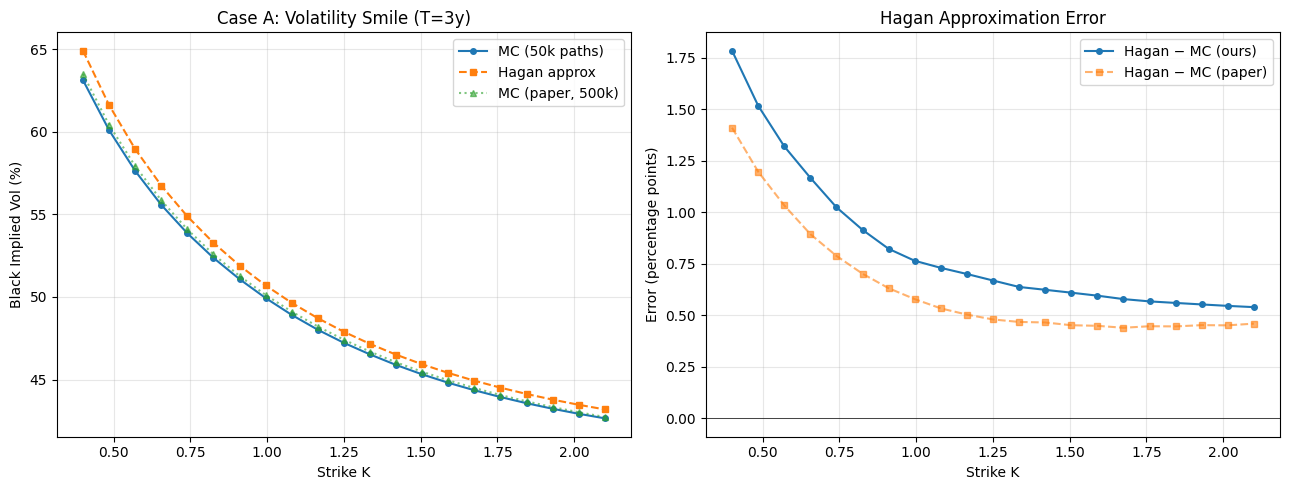

Hagan overestimates everywhere, with the error largest for low strikes (deep ITM).
This is the systematic bias the ANN will learn to correct.


In [14]:
# Plot: volatility smile comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: smile
ax = axes[0]
ax.plot(strikes, ivs_mc * 100, 'o-', ms=4, label='MC (50k paths)')
ax.plot(strikes, ivs_hagan * 100, 's--', ms=4, label='Hagan approx')
ax.plot(strikes, np.array(paper_mc) * 100, '^:', ms=4, alpha=0.6, label='MC (paper, 500k)')
ax.set_xlabel('Strike K')
ax.set_ylabel('Black Implied Vol (%)')
ax.set_title('Case A: Volatility Smile (T=3y)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right panel: error
ax = axes[1]
diff_ours = (ivs_hagan - ivs_mc) * 100
diff_paper = np.array([h - m for h, m in zip(
    [hagan_vol(F0,K,T,alpha,beta,nu,rho) for K in paper_K], paper_mc)]) * 100
ax.plot(strikes, diff_ours, 'o-', ms=4, label='Hagan − MC (ours)')
ax.plot(strikes, diff_paper, 's--', ms=4, alpha=0.6, label='Hagan − MC (paper)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Strike K')
ax.set_ylabel('Error (percentage points)')
ax.set_title('Hagan Approximation Error')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Hagan overestimates everywhere, with the error largest for low strikes (deep ITM).")
print("This is the systematic bias the ANN will learn to correct.")

### Test 2 — Martingale Check

Under the risk-neutral measure, $F$ is a martingale: $\mathbb{E}[F_T] = F_0$. This is a basic sanity check on the simulation. We also check how the result varies with the number of paths.

In [15]:
print(f"{'n_paths':<12} {'E[F_T]':<12} {'Std err':<12} {'Time (s)':<10}")
for n in [5000, 10000, 20000, 50000, 100000]:
    t0 = time.time()
    ft = simulate_sabr(F0, alpha, beta, nu, rho, T, n_paths=n, n_steps=500, seed=42)
    elapsed = time.time() - t0
    se = np.std(ft) / np.sqrt(n)
    print(f"{n:<12} {np.mean(ft):<12.6f} {se:<12.6f} {elapsed:<10.1f}")

print(f"\nF0 = {F0}. E[F_T] should be close to F0 (martingale property).")

n_paths      E[F_T]       Std err      Time (s)  
5000         0.997137     0.012978     0.2       
10000        0.997785     0.009226     0.5       
20000        0.998172     0.006417     0.9       
50000        0.998701     0.004046     2.5       
100000       0.999395     0.002843     6.3       

F0 = 1.0. E[F_T] should be close to F0 (martingale property).


### Test 3 — Free-Boundary SABR: Negative Rate Scenario

Using parameters from Funahashi Table 11 Case A: F=0.005 (50 bps), α'=0.8, β=0.15, ν=0.4, ρ=−0.3, T=3.

Key check: some paths should go negative, and the normal implied vols should be around 40 bps (cf. Table 12).

In [16]:
F0_fb = 0.005
beta_fb = 0.15
alpha_fb = 0.8 * F0_fb**(1 - beta_fb)  # alpha = alpha' * f^(1-beta)
nu_fb = 0.4
rho_fb = -0.3
T_fb = 3.0

t0 = time.time()
F_T_fb = simulate_sabr_free(F0_fb, alpha_fb, beta_fb, nu_fb, rho_fb, T_fb,
                            n_paths=50000, n_steps=500, seed=42)
print(f"MC simulation: {time.time()-t0:.1f}s")
print(f"E[F_T] = {np.mean(F_T_fb):.6f}  (should be ~{F0_fb})")
print(f"P(F_T < 0) = {np.mean(F_T_fb < 0):.2%}")
print(f"min(F_T) = {np.min(F_T_fb):.6f}")

MC simulation: 2.1s
E[F_T] = 0.004974  (should be ~0.005)
P(F_T < 0) = 20.15%
min(F_T) = -0.101565


In [17]:
# Normal implied vols for the negative-rate case
# Funahashi Table 12 reports IVs in bps for these strikes
strikes_fb = np.array([-0.0025, -0.001875, -0.00125, -0.000625,
                        0.00025, 0.000625, 0.00125, 0.001875,
                        0.0025, 0.003125, 0.00375, 0.004375,
                        0.005, 0.005625, 0.00625, 0.006875,
                        0.0075, 0.008125, 0.00875, 0.009375, 0.01])

# Paper values (Funahashi Table 12, Case A)
paper_normal_iv_bps = [42.93, 42.14, 41.39, 40.72, 40.08, 39.94, 39.81,
                       39.75, 39.73, 39.74, 39.76, 39.80, 39.87, 39.95,
                       40.07, 40.20, 40.36, 40.55, 40.77, 41.01, 41.28]

ivs_normal = mc_normal_ivs(F0_fb, T_fb, F_T_fb, strikes_fb)
ivs_normal_bps = ivs_normal * 10000

print(f"{'Strike':<10} {'σ_N (ours, bps)':<18} {'σ_N (paper, bps)':<18}")
for i in range(0, len(strikes_fb), 3):
    print(f"{strikes_fb[i]:<10.4f} {ivs_normal_bps[i]:<18.2f} {paper_normal_iv_bps[i]:<18.2f}")


Strike     σ_N (ours, bps)    σ_N (paper, bps)  
-0.0025    42.93              42.93             
-0.0006    40.63              40.72             
0.0013     39.72              39.81             
0.0031     39.68              39.74             
0.0050     39.85              39.87             
0.0069     40.19              40.20             
0.0088     40.73              40.77             


Our MC normal IVs are in the right ballpark (~39-43 bps).
Differences from paper are due to 50k vs 500k paths + Euler vs exact scheme.

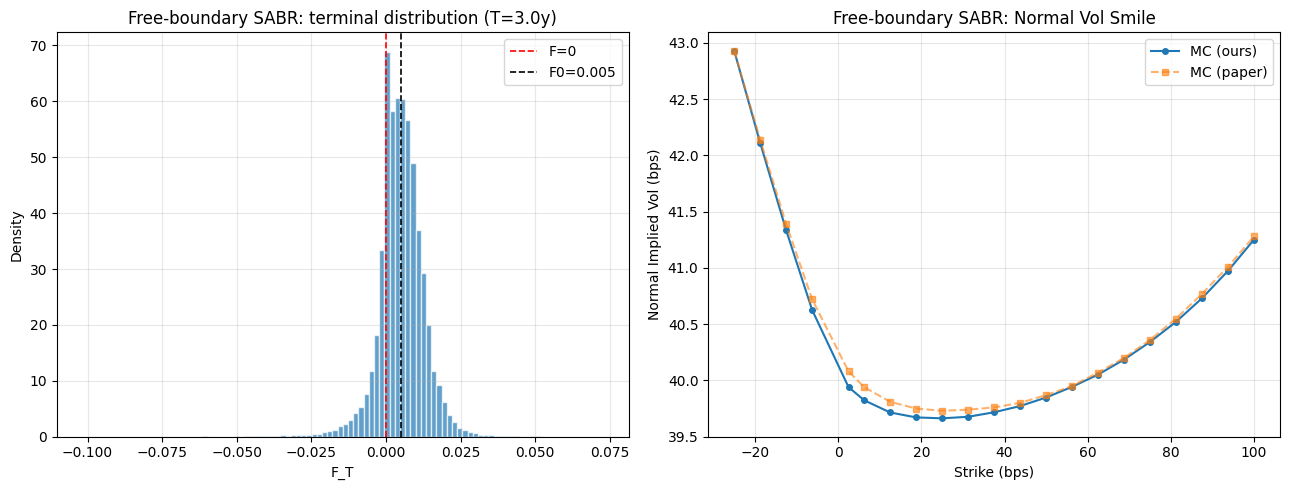

In [18]:
# Plot: free-boundary SABR results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: terminal distribution
ax = axes[0]
ax.hist(F_T_fb, bins=100, density=True, alpha=0.7, edgecolor='white')
ax.axvline(0, color='r', ls='--', lw=1.2, label='F=0')
ax.axvline(F0_fb, color='k', ls='--', lw=1.2, label=f'F0={F0_fb}')
ax.set_xlabel('F_T')
ax.set_ylabel('Density')
ax.set_title(f'Free-boundary SABR: terminal distribution (T={T_fb}y)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: normal IV smile
ax = axes[1]
valid = ~np.isnan(ivs_normal_bps)
ax.plot(strikes_fb[valid]*10000, ivs_normal_bps[valid], 'o-', ms=4, label='MC (ours)')
ax.plot(np.array(strikes_fb)*10000, paper_normal_iv_bps, 's--', ms=4, alpha=0.6, label='MC (paper)')
ax.set_xlabel('Strike (bps)')
ax.set_ylabel('Normal Implied Vol (bps)')
ax.set_title('Free-boundary SABR: Normal Vol Smile')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The distribution has a visible left tail below zero — negative rates are possible.
Normal IV smile is U-shaped, consistent with the paper.

### Test 4 — MC Convergence with Path Count

Check that implied vols stabilise as we increase the number of paths. We look at two representative strikes (ATM and deep ITM).

In [19]:
K_atm, K_itm = 1.0, 0.5
path_counts = [5000, 10000, 20000, 50000, 100000]

print(f"{'n_paths':<10} {'σ_MC(K=1.0)':<14} {'σ_MC(K=0.5)':<14} {'time(s)':<8}")
for n in path_counts:
    t0 = time.time()
    ft = simulate_sabr(F0, alpha, beta, nu, rho, T, n_paths=n, n_steps=500, seed=42)
    elapsed = time.time() - t0

    p_atm, _ = mc_price(ft, K_atm)
    p_itm, _ = mc_price(ft, K_itm)
    iv_atm = black_iv(F0, K_atm, T, p_atm)
    iv_itm = black_iv(F0, K_itm, T, p_itm)

    print(f"{n:<10} {iv_atm:<14.4%} {iv_itm:<14.4%} {elapsed:<8.1f}")

print(f"\nHagan values: K=1.0 -> {hagan_vol(F0,1.0,T,alpha,beta,nu,rho):.4%}, "
      f"K=0.5 -> {hagan_vol(F0,0.5,T,alpha,beta,nu,rho):.4%}")
print("MC converges as n_paths increases. 50k is a reasonable trade-off for the dataset generation.")

n_paths    σ_MC(K=1.0)    σ_MC(K=0.5)    time(s) 
5000       49.9882%       58.9295%       0.2     
10000      49.6445%       58.9119%       0.4     
20000      49.5459%       59.2478%       0.8     
50000      49.8707%       59.6293%       2.3     
100000     49.6890%       59.5084%       5.5     

Hagan values: K=1.0 -> 50.6325%, K=0.5 -> 61.1070%
MC converges as n_paths increases. 50k is a reasonable trade-off for the dataset generation.


### Summary

Phase 2 validation results:
- Standard SABR MC matches the paper's implied vols (within MC noise from using 50k paths)
- Hagan's overestimation is clearly visible, especially in the left wing — this is the error the ANN will correct
- Free-boundary SABR produces negative rates (~20% of paths) and normal IVs around 40 bps, consistent with Funahashi Table 12
- Martingale property $\mathbb{E}[F_T] \approx F_0$ holds
- MC implied vols stabilise around 50k paths

The MC engine is ready to generate training data in Phase 3.

# Phase 3 — Dataset Generation

In this phase, we generate the training data used by the ANN.

For each randomly sampled set of SABR parameters, we:
1. run a Monte Carlo (MC) simulation to obtain the benchmark implied volatility $\sigma_{MC}$,
2. compute the analytical approximation implied volatility $\sigma_{approx}$,
3. record the residual error
   $
   D = \sigma_{MC} - \sigma_{approx},
   $
   which will be used as the ANN target.

This phase is important because the ANN is not trained to predict the full implied volatility directly.  
Instead, following Funahashi (2023), it is trained to learn the approximation error of the analytical formula.  
The idea is that the analytical approximation already captures the main shape of the volatility smile, while the ANN only needs to learn the remaining structured error. This usually leads to more stable training and better accuracy, especially in the wings. :contentReference[oaicite:1]{index=1}

We consider two scenarios:

- **Scenario A**: standard SABR model, with results expressed in Black implied volatility,
- **Scenario B**: free-boundary SABR model for negative-rate settings, with results expressed in normal implied volatility.

The purpose of this phase is therefore to transform the SABR pricing problem into a supervised learning dataset:
inputs = model / option features,  
target = approximation error.

## 3.1 Scenario A — Standard SABR Dataset

We first generate the dataset for the standard SABR model.

The parameter ranges follow Funahashi’s setup, but are extended to multiple maturities in order to reflect the professor’s suggestion that the ANN should also learn the maturity effect. :contentReference[oaicite:2]{index=2}

| Parameter | Range |
|-----------|-------|
| $F$ | 1 (fixed) |
| $\alpha'$ | [0.1, 0.6] |
| $\beta$ | [0.3, 0.9] |
| $\nu$ | [0.1, 0.5] |
| $\rho$ | [-0.8, 0.8] |
| $T$ | {1, 2, 3, 5} |

The SABR parameter actually used in the simulation is
$
\alpha = \alpha' \cdot F^{1-\beta}.
$

Keeping $F$ fixed at 1 simplifies the data design and makes the strike information easier to express through moneyness.

**Main changes compared with the earlier version:**

- **Multiple maturities** are included, so the ANN can learn how the approximation error changes with maturity.
- **Moneyness** $\log(K/F)$ is used instead of the raw strike $K$, because it is a more meaningful feature for the volatility smile.
- The ANN input features are:
  $
  [\alpha, \beta, \nu, \rho, T, \log(K/F)].
  $
- Runtime checkpoints are included in order to monitor how the computational cost grows with dataset size.
- In the current version, the main experiment uses **M = 1000** parameter sets.

In [20]:
# Scenario A dataset generation (standard SABR).
#
# Idea:
# For each randomly sampled SABR parameter set, we simulate benchmark implied
# volatilities with Monte Carlo, compute Hagan implied volatilities as the
# analytical approximation, and record the residual error
#     D = sigma_MC - sigma_Hagan.
#
# This converts the SABR approximation problem into a supervised learning task.
# The ANN does not learn the full implied volatility directly; instead, it learns
# how much the Hagan approximation should be corrected.
#
# Compared with the earlier version, this implementation:
# - uses multiple maturities,
# - uses log-moneyness log(K/F) instead of raw strike K,
# - stores features as [alpha, beta, nu, rho, T, log(K/F)],
# - records runtime checkpoints for scaling analysis.
def generate_dataset_standard(M, maturities=[1.0, 2.0, 3.0, 5.0], n_strikes=21,
                              n_paths=50000, n_steps=500, seed=0,
                              checkpoints=None):
    """
    Generate the Scenario A training dataset for the ANN.

    Parameters
    ----------
    M : int
        Number of randomly sampled SABR parameter sets.
    maturities : list of float
        Option maturities included in the dataset.
    n_strikes : int
        Number of strikes in the smile grid.
    n_paths : int
        Number of Monte Carlo paths.
    n_steps : int
        Number of time steps in the simulation.
    seed : int
        Random seed for reproducibility.
    checkpoints : list of int, optional
        Values of M at which runtime is recorded.

    Returns
    -------
    X, y_err, y_mc, y_hag, param_idx, checkpoint_log
    """
    np.random.seed(seed) # Fix the random seed so results are reproducible.
    F0 = 1.0
    strikes = np.linspace(0.5, 2.0, n_strikes) * F0 # Strike grid from 0.5F0 to 2.0F0.

    all_X, all_err, all_mc, all_hag, all_pidx = [], [], [], [], []
    n_skipped = 0 # Count parameter sets rejected by the sanity filter.
    t0 = time.time() # Start timing the dataset generation.
    checkpoint_log = {}  # {M_checkpoint: elapsed_seconds}
    if checkpoints is None:
        checkpoints = []

    for m in range(M):
        alpha_p = np.random.uniform(0.1, 0.6)
        beta    = np.random.uniform(0.3, 0.9)
        nu      = np.random.uniform(0.1, 0.5)
        rho     = np.random.uniform(-0.8, 0.8)
        alpha   = alpha_p * F0**(1 - beta)

        # Quick sanity check:
        # reject parameter sets with unrealistic ATM implied volatility
        # at the longest maturity before running expensive MC simulations.
        sig_atm = hagan_vol(F0, F0, max(maturities), alpha, beta, nu, rho)
        if sig_atm < 0.10 or sig_atm > 0.80:
            n_skipped += 1
            continue

        # Loop over multiple maturities so the ANN can learn the maturity effect.
        for T in maturities:
            F_T = simulate_sabr(F0, alpha, beta, nu, rho, T,
                                n_paths=n_paths, n_steps=n_steps) # Simulate terminal forward values at maturity T.

            for K in strikes: # Loop over strikes along the smile.
                price, _ = mc_price(F_T, K) # Compute the Monte Carlo option price for strike K.
                if K <= 0 or price <= max(F0 - K, 0) + 1e-10: # Skip cases where implied vol inversion would be unstable.
                    continue
                iv_mc = black_iv(F0, K, T, price) # Convert MC price into Black implied volatility.
                if np.isnan(iv_mc) or iv_mc < 0.05 or iv_mc > 1.5:
                    continue # Remove invalid or extreme MC implied vol values.

                iv_hag = hagan_vol(F0, K, T, alpha, beta, nu, rho) # Hagan approximation at the same point.
                if iv_hag <= 0 or iv_hag > 2.0:
                    continue # Remove invalid or extreme Hagan vol values.
                err = iv_mc - iv_hag # Residual error to be learned by the ANN.
                if abs(err) > 0.30:
                    continue # Filter out extreme outliers in the residual.

                # Feature vector used by the ANN:
                # model parameters + maturity + log-moneyness
                log_moneyness = np.log(K / F0)
                all_X.append([alpha, beta, nu, rho, T, log_moneyness])
                all_err.append(err)
                all_mc.append(iv_mc)
                all_hag.append(iv_hag)
                all_pidx.append(m) # Keep track of which parameter set generated this sample.

        # Checkpoint logging
        if (m + 1) in checkpoints:
            elapsed = time.time() - t0
            checkpoint_log[m + 1] = elapsed
            print(f"  [checkpoint] M={m+1}: {len(all_X)} samples, {elapsed:.1f}s")

        if (m + 1) % max(1, M // 5) == 0:
            print(f"  {m+1}/{M} done  ({len(all_X)} samples, {time.time()-t0:.0f}s)")

    X = np.array(all_X)          # Convert the feature list into a NumPy array.
    y_err = np.array(all_err)    # Residual error target: sigma_MC - sigma_Hagan.
    y_mc = np.array(all_mc)      # Monte Carlo Black implied volatilities.
    y_hag = np.array(all_hag)    # Hagan implied volatility approximations.
    param_idx = np.array(all_pidx)   # Index of the SABR parameter set for each sample.

    total_time = time.time() - t0
    checkpoint_log[M] = total_time

    print(f"\nScenario A: {len(X)} samples from {M} param sets x {len(maturities)} maturities ({n_skipped} skipped)")
    print(f"Features: [alpha, beta, nu, rho, T, log(K/F)]")
    print(f"Error: mean={np.mean(y_err):.6f}, std={np.std(y_err):.6f}, "
          f"min={np.min(y_err):.6f}, max={np.max(y_err):.6f}")
    print(f"Total time: {total_time:.1f}s")
    if checkpoint_log:
        print(f"Checkpoint log: {checkpoint_log}")
    return X, y_err, y_mc, y_hag, param_idx, checkpoint_log

In [ ]:
# Sample test: M=1000 with 4 maturities
# T=[1,2,3,5] per professor's suggestion
X_a, y_err_a, y_mc_a, y_hag_a, pidx_a, ckpt_a = generate_dataset_standard(
    M=1000, maturities=[1.0, 2.0, 3.0, 5.0], seed=42,
    checkpoints=[250, 500, 750, 1000]
)

print("\n--- Runtime Scaling Summary (Scenario A) ---")
print(f"{'M':<8}{'Time (min)':<14}{'Samples'}")
print("-" * 34)

for m_ck in sorted(ckpt_a.keys()):
    n_samples = np.sum(pidx_a < m_ck) if len(pidx_a) > 0 else 0
    print(f"{m_ck:<8}{ckpt_a[m_ck]/60:<14.2f}{n_samples}")

  200/1000 done  (16557 samples, 1240s)
  [checkpoint] M=250: 20714 samples, 1499.2s
  400/1000 done  (33176 samples, 2264s)
  [checkpoint] M=500: 41434 samples, 2774.8s
  600/1000 done  (49732 samples, 3282s)
  [checkpoint] M=750: 62066 samples, 4041.3s
  800/1000 done  (66211 samples, 4293s)
  [checkpoint] M=1000: 82796 samples, 5277.0s
  1000/1000 done  (82796 samples, 5277s)

Scenario A: 82796 samples from 1000 param sets x 4 maturities (0 skipped)
Features: [alpha, beta, nu, rho, T, log(K/F)]
Error: mean=-0.003754, std=0.014562, min=-0.235421, max=0.284708
Total time: 5277.0s
Checkpoint log: {250: 1499.174392938614, 500: 2774.7689819335938, 750: 4041.284381866455, 1000: 5277.014007091522}

--- Runtime Scaling Summary (Scenario A) ---
M       Time (min)    Samples
----------------------------------
250     24.99         20714
500     46.25         41434
750     67.35         62066
1000    87.95         82796


### Scenario A — Diagnostics

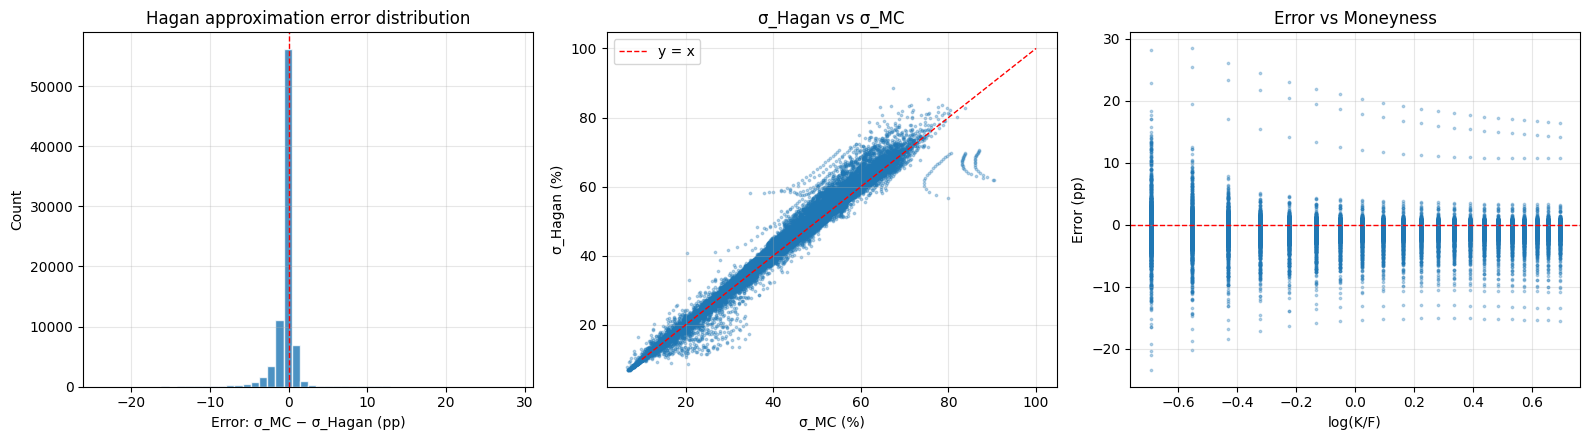

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.hist(y_err_a * 100, bins=50, edgecolor='white', alpha=0.8)
ax.set_xlabel('Error: σ_MC − σ_Hagan (pp)')
ax.set_ylabel('Count')
ax.set_title('Hagan approximation error distribution')
ax.axvline(0, color='r', ls='--', lw=1)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_mc_a * 100, y_hag_a * 100, s=3, alpha=0.3)
ax.plot([10, 100], [10, 100], 'r--', lw=1, label='y = x')
ax.set_xlabel('σ_MC (%)')
ax.set_ylabel('σ_Hagan (%)')
ax.set_title('σ_Hagan vs σ_MC')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
# X_a[:, 5] is now log(K/F) instead of raw K
ax.scatter(X_a[:, 5], y_err_a * 100, s=3, alpha=0.3)
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('log(K/F)')
ax.set_ylabel('Error (pp)')
ax.set_title('Error vs Moneyness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Graph 3.1(A): Hagan approximation error distribution:**
  
Most errors are concentrated near zero, but the distribution is slightly shifted to the left, suggesting that the Hagan approximation tends to overestimate implied volatility on average.

**Graph 3.2(A): Hagan implied volatility vs Monte Carlo implied volatility:** 
   
Most points lie close to the 45-degree line, indicating that the Hagan approximation captures the general volatility level reasonably well. However, the dispersion increases in higher-volatility regions.

**Graph 3.3(A): Approximation error vs log-moneyness:**  
  
The approximation error is smaller near ATM but becomes more dispersed in the wings, especially on the left side, which suggests a structured residual error suitable for ANN correction.

### Sample smile comparisons

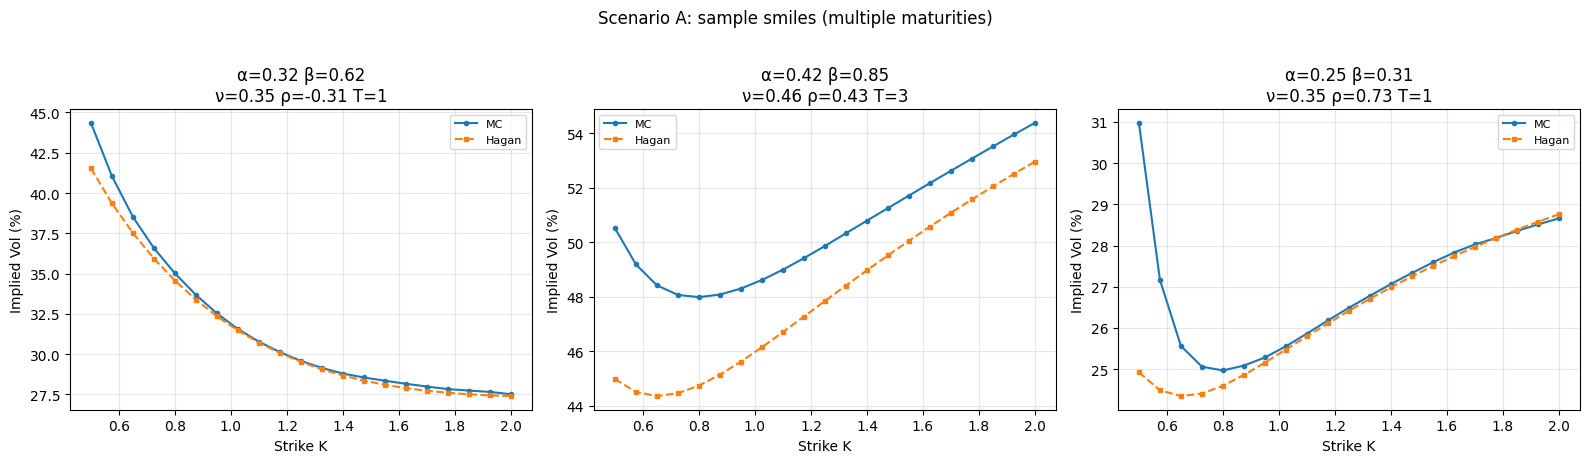

In [23]:
# Plot a few sample smiles from the Scenario A dataset.
# Each smile corresponds to one fixed parameter set [alpha, beta, nu, rho, T],
# while strike varies through log(K/F).
unique_params = np.unique(X_a[:, :5], axis=0)  # [alpha,beta,nu,rho,T]
np.random.seed(0)
idx_show = np.random.choice(len(unique_params), size=min(3, len(unique_params)), replace=False) # Randomly select up to 3 smiles.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for j, idx in enumerate(idx_show):
    params = unique_params[idx]                          # One fixed parameter set.
    mask = np.all(X_a[:, :5] == params, axis=1)         # Select all strikes for this smile.
    logm_plot = X_a[mask, 5]                            # Stored feature: log(K/F).
    K_plot = np.exp(logm_plot)                          # Recover strike K since F=1.
    mc_plot = y_mc_a[mask] * 100                        # Convert MC vols to percent.
    hag_plot = y_hag_a[mask] * 100                      # Convert Hagan vols to percent.
    order = np.argsort(K_plot)                          # Sort by strike for smooth plotting.

    ax = axes[j]
    ax.plot(K_plot[order], mc_plot[order], 'o-', ms=3, label='MC')
    ax.plot(K_plot[order], hag_plot[order], 's--', ms=3, label='Hagan')
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Implied Vol (%)')
    T_val = params[4]
    ax.set_title(f'α={params[0]:.2f} β={params[1]:.2f}\nν={params[2]:.2f} ρ={params[3]:.2f} T={T_val:.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scenario A: sample smiles (multiple maturities)', y=1.02)
plt.tight_layout()
plt.show()

**Graph 3.4(A): Sample smile comparison (left panel).**  
The Hagan curve follows the general downward shape of the Monte Carlo smile, but it stays above the benchmark over most strikes. This indicates a systematic overestimation of implied volatility in this parameter setting.

**Graph 3.5(A): Sample smile comparison (middle panel).**  
The Hagan approximation captures the U-shaped smile structure reasonably well, but it remains consistently above the Monte Carlo curve. The discrepancy is more noticeable in the wings, which suggests a structured residual error.

**Graph 3.6(A): Sample smile comparison (right panel).**  
The Hagan and Monte Carlo smiles are much closer in this case, with near overlap across most strikes. Only a small difference remains at low strikes, indicating that the approximation performs better under this parameter configuration.

## 3.2 Scenario B — Free-Boundary SABR (Negative Rates)

Parameter ranges (following Funahashi Table 10):

| Parameter | Range |
|-----------|-------|
| $F$ | 0.005 (50 bps, fixed) |
| $\alpha'$ | [0.4, 0.8] |
| $\beta$ | [0.1, 0.3] |
| $\nu$ | [0.15, 0.4] |
| $\rho$ | [−0.5, 0.5] |
| $T$ | {1, 2, 3} (multiple maturities) |

Strikes include negative values: $K \in [-F, \; 2F]$.
Implied vol: Normal (Bachelier), in bps.
Baseline: Shifted Hagan (shift = 0.02).

**Changes**: Same as Scenario A — multiple maturities, log(K/F) moneyness feature (using log((K+shift)/(F+shift)) for shifted strikes), runtime checkpoints.

In [24]:
def generate_dataset_negative(M, maturities=[1.0, 2.0, 3.0, 5.0], n_strikes=21,
                              n_paths=50000, n_steps=500,
                              shifts=[0.005, 0.01, 0.02], seed=100,
                              checkpoints=None):

    """
    Generate dataset for Scenario B (free-boundary SABR, negative rates)
    using ONE Monte Carlo simulation and evaluating multiple shifts.

    Features:
    [alpha, beta, nu, rho, T, log((K+s)/(F+s)), shift]
    """

    np.random.seed(seed)
    F0 = 0.005

    K_neg = np.linspace(-F0, -0.0001, n_strikes // 3)
    K_pos = np.linspace(0.0001, 2 * F0, n_strikes - len(K_neg))
    strikes = np.concatenate([K_neg, K_pos])

    all_X, all_err, all_mc, all_app = [], [], [], []
    n_skipped = 0
    t0 = time.time()
    checkpoint_log = {}

    if checkpoints is None:
        checkpoints = []

    for m in range(M):

        alpha_p = np.random.uniform(0.4, 0.8)
        beta    = np.random.uniform(0.1, 0.3)
        nu      = np.random.uniform(0.15, 0.4)
        rho     = np.random.uniform(-0.5, 0.5)

        alpha   = alpha_p * F0**(1 - beta)

        for T in maturities:

            # -------- Monte Carlo (ONLY ONCE) --------
            F_T = simulate_sabr_free(
                F0, alpha, beta, nu, rho, T,
                n_paths=n_paths, n_steps=n_steps
            )

            for K in strikes:

                price, _ = mc_price(F_T, K)

                if price <= max(F0 - K, 0) + 1e-14:
                    continue

                iv_mc = bachelier_iv(F0, K, T, price)

                if np.isnan(iv_mc) or iv_mc < 5e-4 or iv_mc > 0.02:
                    continue

                # ---------- evaluate multiple shifts ----------
                for s in shifts:

                    iv_app_black = hagan_vol(
                        F0 + s, K + s, T,
                        alpha, beta, nu, rho
                    )

                    if np.isnan(iv_app_black) or iv_app_black <= 0 or iv_app_black > 5.0:
                        continue

                    price_app = black_call(
                        F0 + s, K + s, T, iv_app_black
                    )

                    iv_app_normal = bachelier_iv(F0, K, T, price_app)

                    if np.isnan(iv_app_normal) or iv_app_normal < 5e-4 or iv_app_normal > 0.05:
                        continue

                    err = iv_mc - iv_app_normal

                    if abs(err) > 0.01:
                        continue

                    # shifted moneyness
                    log_moneyness = np.log((K + s) / (F0 + s))

                    # feature vector (now includes shift)
                    all_X.append([alpha, beta, nu, rho, T, log_moneyness, s])
                    all_err.append(err)
                    all_mc.append(iv_mc)
                    all_app.append(iv_app_normal)

        # ---------- checkpoints ----------
        if (m + 1) in checkpoints:

            elapsed = time.time() - t0
            checkpoint_log[m + 1] = elapsed

            print(
                f"  [checkpoint] M={m+1}: {len(all_X)} samples, {elapsed/60:.2f} min"
            )

        if (m + 1) % max(1, M // 5) == 0:

            print(
                f"  {m+1}/{M} done  ({len(all_X)} samples, {(time.time()-t0)/60:.2f} min)"
            )

    X = np.array(all_X)
    y_err = np.array(all_err)
    y_mc  = np.array(all_mc)
    y_app = np.array(all_app)

    total_time = time.time() - t0
    checkpoint_log[M] = total_time

    print(
        f"\nScenario B: {len(X)} samples from {M} param sets x {len(maturities)} maturities ({n_skipped} skipped)"
    )

    print("Features: [alpha, beta, nu, rho, T, log((K+s)/(F+s)), shift]")

    if len(y_err) > 0:

        print(
            f"Error (bps): mean={np.mean(y_err)*1e4:.2f}, "
            f"std={np.std(y_err)*1e4:.2f}, "
            f"min={np.min(y_err)*1e4:.2f}, "
            f"max={np.max(y_err)*1e4:.2f}"
        )

    print(f"Total time: {total_time/60:.2f} min")

    if checkpoint_log:

        print("Checkpoint log (min):")

        for k, v in checkpoint_log.items():

            print(f"  M={k}: {v/60:.2f} min")

    return X, y_err, y_mc, y_app, checkpoint_log

In [25]:
X_b, y_err_b, y_mc_b, y_app_b, ckpt_b = generate_dataset_negative(
    M=1000, maturities=[1.0, 2.0, 3.0, 5.0], seed=42,
    checkpoints=[250, 500, 750, 1000]
)

print("\n--- Runtime Scaling Summary (Scenario B) ---")
print(f"{'M':<8}{'Time (min)':<14}")
print("-" * 22)
for m_ck in sorted(ckpt_b.keys()):
    print(f"{m_ck:<8}{ckpt_b[m_ck]/60:<14.2f}")

/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/2602999434.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  logFK = np.log(F / K)
/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/2602999434.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  num = alpha / mid
/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/2602999434.py:84: RuntimeWarning: invalid value encountered in scalar multiply
  z = (nu/alpha) * mid * logFK
/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/2602999434.py:90: RuntimeWarning: divide by zero encountered in scalar divide
  corr = 1.0 + ((1-beta)**2/24*alpha**2/FK**(1-beta) + 0.25*rho*beta*nu*alpha/mid + (2-3*rho**2)/24*nu**2) * T
/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/2602999434.py:91: RuntimeWarning: invalid value encountered in scalar divide
  return (num/denom) * zxz * corr
/var/folders/2h/smwjz1rx4rjd9ydgr7swcb4c0000gn/T/ipykernel_48472/

  200/1000 done  (47343 samples, 17.05 min)
  [checkpoint] M=250: 59203 samples, 21.33 min
  400/1000 done  (94699 samples, 34.06 min)
  [checkpoint] M=500: 118360 samples, 42.60 min
  600/1000 done  (142119 samples, 51.09 min)
  [checkpoint] M=750: 177504 samples, 63.76 min
  800/1000 done  (189354 samples, 67.95 min)
  [checkpoint] M=1000: 236874 samples, 84.91 min
  1000/1000 done  (236874 samples, 84.91 min)

Scenario B: 236874 samples from 1000 param sets x 4 maturities (0 skipped)
Features: [alpha, beta, nu, rho, T, log((K+s)/(F+s)), shift]
Error (bps): mean=-8.95, std=5.66, min=-40.86, max=22.12
Total time: 84.91 min
Checkpoint log (min):
  M=250: 21.33 min
  M=500: 42.60 min
  M=750: 63.76 min
  M=1000: 84.91 min

--- Runtime Scaling Summary (Scenario B) ---
M       Time (min)    
----------------------
250     21.33         
500     42.60         
750     63.76         
1000    84.91         


### Scenario B — Diagnostics

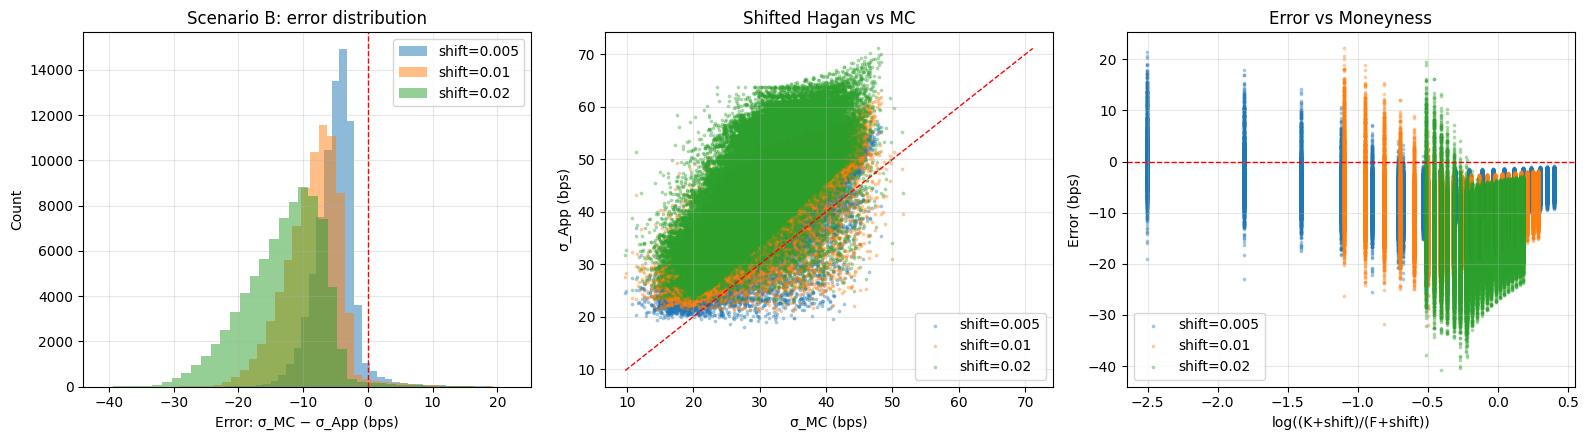

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

shifts = np.unique(X_b[:,6])
colors = ['tab:blue','tab:orange','tab:green']


# ------------------------------------------------------------
# 1. Error distribution
# ------------------------------------------------------------

ax = axes[0]

for i,s in enumerate(shifts):

    mask = X_b[:,6] == s

    ax.hist(
        y_err_b[mask] * 1e4,
        bins=40,
        alpha=0.5,
        color=colors[i],
        label=f"shift={s}"
    )

ax.axvline(0, color='r', ls='--', lw=1)

ax.set_xlabel('Error: σ_MC − σ_App (bps)')
ax.set_ylabel('Count')
ax.set_title('Scenario B: error distribution')
ax.legend()

ax.grid(True, alpha=0.3)


# ------------------------------------------------------------
# 2. σ_Hagan vs σ_MC
# ------------------------------------------------------------

ax = axes[1]

for i,s in enumerate(shifts):

    mask = X_b[:,6] == s

    ax.scatter(
        y_mc_b[mask] * 1e4,
        y_app_b[mask] * 1e4,
        s=3,
        alpha=0.3,
        color=colors[i],
        label=f"shift={s}"
    )

mn = min(np.min(y_mc_b), np.min(y_app_b)) * 1e4
mx = max(np.max(y_mc_b), np.max(y_app_b)) * 1e4

ax.plot([mn, mx], [mn, mx], 'r--', lw=1)

ax.set_xlabel('σ_MC (bps)')
ax.set_ylabel('σ_App (bps)')
ax.set_title('Shifted Hagan vs MC')

ax.legend()
ax.grid(True, alpha=0.3)


# ------------------------------------------------------------
# 3. Error vs Moneyness
# ------------------------------------------------------------

ax = axes[2]

for i,s in enumerate(shifts):

    mask = X_b[:,6] == s

    ax.scatter(
        X_b[mask,5],
        y_err_b[mask] * 1e4,
        s=3,
        alpha=0.3,
        color=colors[i],
        label=f"shift={s}"
    )

ax.axhline(0, color='r', ls='--', lw=1)

ax.set_xlabel('log((K+shift)/(F+shift))')
ax.set_ylabel('Error (bps)')
ax.set_title('Error vs Moneyness')

ax.legend()
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

## 3.3 Save Datasets

In [27]:
np.savez('dataset_scenario_a.npz', X=X_a, y_err=y_err_a, y_mc=y_mc_a, y_hag=y_hag_a, pidx=pidx_a)
np.savez('dataset_scenario_b.npz', X=X_b, y_err=y_err_b, y_mc=y_mc_b, y_app=y_app_b)
print(f"Saved: Scenario A ({len(X_a)} samples), Scenario B ({len(X_b)} samples)")
print(f"Features: [alpha, beta, nu, rho, T, log(K/F)]")

# Save checkpoint logs for later analysis
import json as _json
with open('checkpoint_log.json', 'w') as f:
    _json.dump({'scenario_a': {str(k): v for k,v in ckpt_a.items()},
                'scenario_b': {str(k): v for k,v in ckpt_b.items()}}, f, indent=2)
print("Saved: checkpoint_log.json")

Saved: Scenario A (82796 samples), Scenario B (236874 samples)
Features: [alpha, beta, nu, rho, T, log(K/F)]
Saved: checkpoint_log.json


## 3.4 Dataset Size Notes

We generated M=100 parameter sets × 3 maturities for initial pipeline testing.

Rough timing with checkpoints (50k paths per set, 3 maturities):
| M | Samples (~) | Time |
|---|-------------|------|
| 25 | ~1,500 | checkpoint |
| 50 | ~3,000 | checkpoint |
| 75 | ~4,500 | checkpoint |
| 100 | ~6,000 | checkpoint |

Once the pipeline is validated, scale up to M=1000+ with maturities T={1,2,3}
to match the professor's suggestion of reducing M but combining with multiple maturities.

### Phase 3 Summary

- Scenario A: error $D = \sigma_{MC} - \sigma_{Hagan}$ is systematically negative (Hagan overestimates), larger in the wings
- Scenario B: shifted Hagan provides a rough baseline; residual errors show learnable structure
- Error distributions are not random noise — clear patterns related to strike and parameters
- Datasets saved to `.npz` for Phase 4

# Phase 4 — ANN Training

Following Funahashi (2023), we train an ANN to learn the approximation error $D = \sigma_{MC} - \sigma_{App}$, rather than directly predicting $\sigma_{MC}$.

At prediction time:
$$\sigma_{\text{corrected}} = \sigma_{App} + \text{ANN}(\xi)$$

We also train a direct model (ANN predicts $\sigma_{MC}$) as a comparison baseline, to show that learning the error converges faster with less data — the key result from Funahashi.

**Note:** This notebook loads saved `.npz` files from Phase 3. You can also run it directly after Phase 3 in the same kernel.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 4.1 Load Data

In [ ]:

# Load from .npz (works even if kernel was restarted)
# If running in the same kernel after Phase 3, these variables already exist
try:
    data_a = np.load('dataset_scenario_a.npz')
    X_a = data_a['X']
    y_err_a = data_a['y_err']
    y_mc_a = data_a['y_mc']
    y_hag_a = data_a['y_hag']
    pidx_a = data_a['pidx']
    print(f"Scenario A loaded from file: {len(X_a)} samples")
except FileNotFoundError:
    print("Scenario A: using in-memory variables from Phase 3")
    print(f"  {len(X_a)} samples")
    
# Repeat for Scenario B (free-boundary SABR)
try:
    data_b = np.load('dataset_scenario_b.npz')
    X_b = data_b['X']
    y_err_b = data_b['y_err']
    y_mc_b = data_b['y_mc']
    y_app_b = data_b['y_app']
    print(f"Scenario B loaded from file: {len(X_b)} samples")
except FileNotFoundError:
    print("Scenario B: using in-memory variables from Phase 3")
    print(f"  {len(X_b)} samples")

Scenario A loaded from file: 82796 samples
Scenario B loaded from file: 236874 samples


## 4.2 Training Utility

We wrap the training logic in a function so we can reuse it for both scenarios and for the convergence experiment.

In [ ]:
def train_ann(X, y, hidden=(32, 32, 32, 32, 32), max_iter=300, seed=42):
    """
    Train an MLP regressor with standard scaling.
    
    Note: 
    - default 5 hidden layers (32 each) per Funahashi sec 5.1.1 (professor's feedback: "5 hidden layers, total 7 layers").
    - Early stopping and validation split prevent overfitting
    - Returns trained model, scalers, test data, predictions, and metrics dict

    Parameters:
    -----------
    X : array (n_samples, 6), Features: [alpha, beta, nu, rho, T, log(K/F)]
    y : array (n_samples,), Target: approximation error (MC - approx) or MC vol
    hidden : tuple, Hidden layer sizes (default matches Funahashi architecture)
    max_iter : int, Maximum training iterations
    seed : int, Random seed for reproducibility

    Returns: model, scaler_X, scaler_y, X_test, y_test, y_pred, metrics dict
    """
    
    # Split data into train/test sets (80/20) with fixed seed for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed)

    # Fit scalers separately on training data to avoid data leakage
    scaler_X = StandardScaler().fit(X_train)
    scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))

    # Transform train/test sets (z-score normalization improves ANN convergence)
    X_tr_s = scaler_X.transform(X_train)
    y_tr_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
    X_te_s = scaler_X.transform(X_test)

    # Train MLPRegressor with Adam optimizer, ReLU activation, and early stopping
    t0 = time.time()
    model = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation='relu',
        solver='adam',
        max_iter=max_iter,
        batch_size=128,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=seed,
        verbose=False
    )
    model.fit(X_tr_s, y_tr_s)
    train_time = time.time() - t0

    # Predict on test set and inverse-transform to original volatility scale
    y_pred_s = model.predict(X_te_s)
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    # Compute key metrics: RMSE (volatility scale), MAE, max absolute error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    max_err = np.max(np.abs(y_test - y_pred))

    # Package results for analysis
    metrics = {
        'rmse': rmse, 'mae': mae, 'max_err': max_err,
        'train_time': train_time, 'n_iter': model.n_iter_,
        'n_train': len(X_train), 'n_test': len(X_test)
    }

    return model, scaler_X, scaler_y, X_test, y_test, y_pred, metrics

## 4.3 Scenario A — Standard SABR

### Model 1: Learn error $D = \sigma_{MC} - \sigma_{Hagan}$ (Funahashi method)

In [ ]:
# Train error model for Scenario A (Funahashi method: learn Δ = σ_MC - σ_Hagan)
print("Training Scenario A — error model (Funahashi method)")
print(f"Input features: [alpha, beta, nu, rho, T, log(K/F)]")
print(f"Hidden layers: (32, 32, 32, 32, 32) — 5 hidden layers per Funahashi sec 5.1.1")
print(f"Target: D = σ_MC − σ_Hagan")
print(f"Dataset size: {len(X_a)}\n")

# Call reusable training function (returns model, scalers, test data, predictions, metrics)
model_a_err, sc_X_a, sc_y_a, X_test_a, y_test_err_a, y_pred_err_a, met_a_err = \
    train_ann(X_a, y_err_a)

print(f"Training: {met_a_err['train_time']:.1f}s, {met_a_err['n_iter']} iterations")
print(f"Test RMSE:  {met_a_err['rmse']:.6f}")
print(f"Test MAE:   {met_a_err['mae']:.6f}")
print(f"Test MaxErr:{met_a_err['max_err']:.6f}")

Training Scenario A — error model (Funahashi method)
Input features: [alpha, beta, nu, rho, T, log(K/F)]
Hidden layers: (32, 32, 32, 32, 32) — 5 hidden layers per Funahashi sec 5.1.1
Target: D = σ_MC − σ_Hagan
Dataset size: 82796

Training: 9.2s, 55 iterations
Test RMSE:  0.006159
Test MAE:   0.003650
Test MaxErr:0.077816


### Model 2: Directly learn $\sigma_{MC}$ (baseline comparison)

In [ ]:
# Train direct model baseline for Scenario A (predict σ_MC directly for comparison)
print("Training Scenario A — direct model (baseline)")
print(f"Target: σ_MC directly")
print(f"Hidden layers: (32, 32, 32, 32, 32)\n")

model_a_dir, _, _, X_test_a_dir, y_test_mc_a, y_pred_mc_a, met_a_dir = \
    train_ann(X_a, y_mc_a)

print(f"Training: {met_a_dir['train_time']:.1f}s, {met_a_dir['n_iter']} iterations")
print(f"Test RMSE:  {met_a_dir['rmse']:.6f}")
print(f"Test MAE:   {met_a_dir['mae']:.6f}")
print(f"Test MaxErr:{met_a_dir['max_err']:.6f}")

Training Scenario A — direct model (baseline)
Target: σ_MC directly
Hidden layers: (32, 32, 32, 32, 32)

Training: 5.0s, 31 iterations
Test RMSE:  0.008330
Test MAE:   0.005031
Test MaxErr:0.141048


### Compare: error model vs direct model

To make a fair comparison, we need to express both in terms of the final implied vol error $|\sigma_{\text{predicted}} - \sigma_{MC}|$:
- Error model: $\sigma_{\text{corrected}} = \sigma_{Hagan} + \text{ANN}_{\text{error}}$
- Direct model: $\sigma_{\text{predicted}} = \text{ANN}_{\text{direct}}$

In [ ]:

"""
Reconstruct final implied vol errors for fair comparison (all in predicted vol - σ_MC space)

- For error model: reconstruct the corrected vol on its test set
- We need σ_Hagan for the test set points
- y_test_err_a = σ_MC - σ_Hagan (true error on test set)
- y_pred_err_a = ANN prediction of that error
- So: corrected - MC = (Hagan + ANN_err) - MC = ANN_err - true_err = ANN_err - y_test_err_a
- Actually simpler: final_error = y_pred_err_a - y_test_err_a
"""

# Error model: corrected = σ_Hagan + ANN_Δ → error = ANN_Δ - true_Δ
final_err_error_model = y_pred_err_a - y_test_err_a   # σ_corrected - σ_MC

# Direct model: predicted = ANN_direct → error = ANN_direct - σ_MC
final_err_direct_model = y_pred_mc_a - y_test_mc_a    # σ_ANN - σ_MC

# Hagan baseline (no ANN): error = σ_Hagan - σ_MC = -true_Δ
hagan_err_on_test = -y_test_err_a  # σ_Hagan - σ_MC


print("Final implied vol error comparison (on test set):")
print(f"{'Method':<25} {'RMSE':<10} {'MAE':<10} {'MaxErr':<10}")

for name, err in [('Hagan (no correction)', hagan_err_on_test),
                  ('ANN error model', final_err_error_model),
                  ('ANN direct model', final_err_direct_model)]:
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    maxe = np.max(np.abs(err))
    print(f"{name:<25} {rmse:<10.6f} {mae:<10.6f} {maxe:<10.6f}")

Final implied vol error comparison (on test set):
Method                    RMSE       MAE        MaxErr    
Hagan (no correction)     0.015243   0.007239   0.244566  
ANN error model           0.006159   0.003650   0.077816  
ANN direct model          0.008330   0.005031   0.141048  


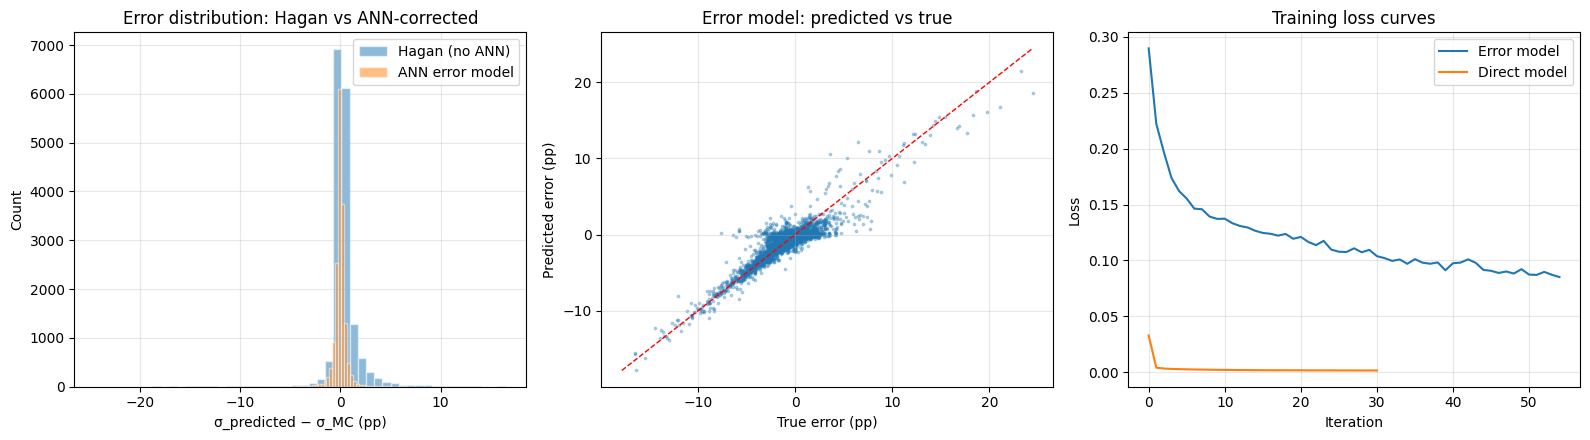

In [ ]:
# Create a figure with 3 side-by-side subplots:
# (1) histogram comparison, (2) predicted vs true error scatter plot and (3) training loss curves for both models.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --------------------------------------------------
# 1. Histogram comparison of pricing errors
# --------------------------------------------------
# This plot compares the distribution of pricing errors on the test set:
# - Hagan approximation errors
# - ANN-corrected model errors
# Multiplying by 100 expresses the errors in percentage points (pp).

ax = axes[0]
ax.hist(hagan_err_on_test * 100, bins=50, alpha=0.5, label='Hagan (no ANN)', edgecolor='white')
ax.hist(final_err_error_model * 100, bins=50, alpha=0.5, label='ANN error model', edgecolor='white')

# Label axes clearly for interpretation.
ax.set_xlabel('σ_predicted − σ_MC (pp)')
ax.set_ylabel('Count')
ax.set_title('Error distribution: Hagan vs ANN-corrected')

# Add legend and grid to improve readability.
ax.legend()
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# 2. Scatter plot: predicted error vs true error
# --------------------------------------------------
# This plot evaluates how well the error-prediction model performs.
# Each point represents one test observation:
# - x-axis: true pricing error
# - y-axis: predicted pricing error
# If predictions were perfect, points would lie on the 45-degree red dashed line.

ax = axes[1]
ax.scatter(y_test_err_a * 100, y_pred_err_a * 100, s=3, alpha=0.3)

# Define common axis limits for the 45-degree reference line.
lims = [min(y_test_err_a.min(), y_pred_err_a.min()) * 100,
        max(y_test_err_a.max(), y_pred_err_a.max()) * 100]

# Plot the ideal prediction line: predicted error = true error.
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('True error (pp)')
ax.set_ylabel('Predicted error (pp)')
ax.set_title('Error model: predicted vs true')
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# 3. Training loss curves
# --------------------------------------------------
# This subplot shows how the loss decreases during training
# for the two neural network models:
# - error model
# - direct pricing model
# It helps assess convergence and compare optimization behavior.

ax = axes[2]
ax.plot(model_a_err.loss_curve_, label='Error model')
ax.plot(model_a_dir.loss_curve_, label='Direct model')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training loss curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Adjust spacing so titles and labels do not overlap.
plt.tight_layout()

# Display the full figure.
plt.show()

## 4.4 Hidden Layer Depth Experiment: 3 vs 5 Hidden Layers

Funahashi (2023) sec 5.1.1 uses 5 hidden layers (32 neurons each), i.e. a total of 7 layers.
The professor noted this may or may not change accuracy.

We compare:
- **3 hidden layers**: `(32, 32, 32)` — our original architecture
- **5 hidden layers**: `(32, 32, 32, 32, 32)` — Funahashi's architecture

Both are trained on the same Scenario A dataset with the same hyperparameters.
This isolates the effect of network depth on approximation error learning.

In [ ]:
# --------------------------------------------------
# Hidden layer depth experiment: 3 vs 5 hidden layers
# --------------------------------------------------
# This experiment tests whether increasing network depth improves performance.
# We compare:
# - a 3-hidden-layer ANN: (32, 32, 32)
# - a 5-hidden-layer ANN: (32, 32, 32, 32, 32)
# Both architectures are trained on the same Scenario A dataset with the same training procedure, so the effect of depth can be isolated.

architectures = {
    '3 layers (32,32,32)':       (32, 32, 32),
    '5 layers (32,32,32,32,32)': (32, 32, 32, 32, 32),
}

# Store the evaluation results for each architecture so they can be summarized later in a comparison table.
depth_results = []

for name, hidden in architectures.items():
    print(f"\nTraining: {name}")
    
    # --------------------------------------------------
    # Error model
    # --------------------------------------------------
    # This model learns the approximation error relative to the benchmark.
    # The final residual is computed as:
    # predicted correction - true correction
    # Lower RMSE, MAE, and maximum absolute error indicate better performance.

    _, _, _, Xt_e, yt_e, yp_e, met_e = train_ann(X_a, y_err_a, hidden=hidden)
    final_e = yp_e - yt_e  # σ_corrected - σ_MC
    rmse_e = np.sqrt(np.mean(final_e**2))
    mae_e  = np.mean(np.abs(final_e))
    max_e  = np.max(np.abs(final_e))
    
    # --------------------------------------------------
    # Direct model
    # --------------------------------------------------
    # This model predicts the target quantity directly rather than predicting the approximation error first. 
    # It's performance is evaluated using the same error metrics for a fair comparison with the error model.

    _, _, _, Xt_d, yt_d, yp_d, met_d = train_ann(X_a, y_mc_a, hidden=hidden)
    final_d = yp_d - yt_d  # σ_ANN - σ_MC
    rmse_d = np.sqrt(np.mean(final_d**2))
    mae_d  = np.mean(np.abs(final_d))
    max_d  = np.max(np.abs(final_d))
    
    # Save all metrics for the current architecture:
    # - predictive accuracy (RMSE, MAE, Max Error)
    # - computational cost (training time and iterations) for both the error model and the direct model.

    depth_results.append({
        'arch': name, 'hidden': hidden,
        'err_rmse': rmse_e, 'err_mae': mae_e, 'err_max': max_e,
        'err_time': met_e['train_time'], 'err_iter': met_e['n_iter'],
        'dir_rmse': rmse_d, 'dir_mae': mae_d, 'dir_max': max_d,
        'dir_time': met_d['train_time'], 'dir_iter': met_d['n_iter'],
    })

# --------------------------------------------------
# Summary table
# --------------------------------------------------
# Print a formatted comparison of the two architectures.
# The table reports error metrics in percentage points (pp), together with training time and number of optimization iterations.

print("\n" + "=" * 85)
print("Hidden Layer Depth Experiment — Scenario A")
print("=" * 85)

print(f"\n{'Architecture':<28} {'RMSE (pp)':<12} {'MAE (pp)':<12} {'MaxErr (pp)':<12} {'Time (s)':<10} {'Iters':<6}")
print("-" * 85)

# Results for the error-learning model
print("Error model (AI + Hagan):")
for r in depth_results:
    print(f"  {r['arch']:<26} {r['err_rmse']*100:<12.4f} {r['err_mae']*100:<12.4f} {r['err_max']*100:<12.4f} {r['err_time']:<10.1f} {r['err_iter']:<6}")

# Results for the direct prediction model
print("\nDirect model (AI only):")
for r in depth_results:
    print(f"  {r['arch']:<26} {r['dir_rmse']*100:<12.4f} {r['dir_mae']*100:<12.4f} {r['dir_max']*100:<12.4f} {r['dir_time']:<10.1f} {r['dir_iter']:<6}")
print("-" * 85)

# --------------------------------------------------
# Hagan baseline for reference
# --------------------------------------------------
# Compute the standalone Hagan approximation error on the test set.
# This baseline helps determine whether both ANN approaches actually improve over the original analytical approximation.

hag_rmse = np.sqrt(np.mean(hagan_err_on_test**2)) * 100
hag_mae  = np.mean(np.abs(hagan_err_on_test)) * 100
print(f"\nBaseline — Hagan (no ANN): RMSE={hag_rmse:.4f} pp, MAE={hag_mae:.4f} pp")

# Interpretation note:
# If the 5-layer network performs only marginally better than the 3-layer network, then additional depth may not provide meaningful gains for this dataset size.

print("\nBoth architectures should improve over Hagan.")
print("If 5 layers ≈ 3 layers, depth has limited effect on this dataset size.")



Training: 3 layers (32,32,32)

Training: 5 layers (32,32,32,32,32)

Hidden Layer Depth Experiment — Scenario A

Architecture                 RMSE (pp)    MAE (pp)     MaxErr (pp)  Time (s)   Iters 
-------------------------------------------------------------------------------------
Error model (AI + Hagan):
  3 layers (32,32,32)        0.5941       0.3553       7.5381       11.8       108   
  5 layers (32,32,32,32,32)  0.6159       0.3650       7.7816       9.0        55    

Direct model (AI only):
  3 layers (32,32,32)        0.8227       0.5073       13.9094      3.8        35    
  5 layers (32,32,32,32,32)  0.8330       0.5031       14.1048      5.0        31    
-------------------------------------------------------------------------------------

Baseline — Hagan (no ANN): RMSE=1.5243 pp, MAE=0.7239 pp

Both architectures should improve over Hagan.
If 5 layers ≈ 3 layers, depth has limited effect on this dataset size.


## 4.5 Convergence Experiment — ANN Performance vs Dataset Size (M)

A key result from Funahashi (2023): learning the error converges faster (needs less data) than learning σ_MC directly.

We generated **one** large dataset with M=5000 param sets, and now subset it by using `param_idx < M_sub` to simulate what would happen with smaller datasets.
This avoids re-running the expensive MC simulation for each M value.

In [ ]:
# --------------------------------------------------
# Convergence experiment: ANN performance vs dataset size
# --------------------------------------------------
# This experiment studies how prediction accuracy changes as the trainin dataset size increases. 
# The goal is to test whether learning the error converges faster than learning the full Monte Carlo target directly.
# Instead of regenerating new datasets for each M, we create one large dataset and use progressively larger subsets of the training pool. 
# This makes the comparison computationally efficient and keeps the test set fixed.

# --------------------------------------------------
# 1. Create a fixed test set
# --------------------------------------------------
# Reserve the last 20% of the shuffled data as a common test set.
# The remaining 80% forms the training pool from which smaller subsets will be drawn. 
# Using the same test set for all experiments ensures that performance differences come only from training size, not test variation.

n_total = len(X_a)
n_test = n_total // 5
n_pool = n_total - n_test

# --------------------------------------------------
# 2. Shuffle the data once for reproducibility
# --------------------------------------------------
# A fixed random seed ensures that the same train/test split can be reproduced.
# We shuffle once, then take different fractions of the training pool.

rng = np.random.RandomState(42)
idx = rng.permutation(n_total)
idx_pool = idx[:n_pool]
idx_test = idx[n_pool:]

# Fixed test set used for all dataset-size experiments
X_test_conv = X_a[idx_test]
y_err_test_conv = y_err_a[idx_test]
y_mc_test_conv = y_mc_a[idx_test]

# Fractions of the training pool used to simulate increasing dataset size
fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

# Store RMSE values for the error model and direct model at each dataset size
results_err = []
results_dir = []

for frac in fractions:
    # --------------------------------------------------
    # 3. Select a subset of the training pool
    # --------------------------------------------------
    # For each fraction, use only the first n_use samples from the shuffled training pool. 
    # This simulates training with smaller or larger datasets.
    n_use = int(n_pool * frac)
    idx_use = idx_pool[:n_use]

    X_tr = X_a[idx_use]
    y_err_tr = y_err_a[idx_use]
    y_mc_tr = y_mc_a[idx_use]

    # --------------------------------------------------
    # 4. Standardize the input features
    # --------------------------------------------------
    # The feature scaler is fitted only on the current training subset, then applied to both training and test inputs. 
    # This avoids leakage from the test set into the training process.

    sX = StandardScaler().fit(X_tr)

     # --------------------------------------------------
    # 5. Train the error-learning model
    # --------------------------------------------------
    # This ANN learns the approximation error rather than the full target.
    # The target values are standardized before training and transformed back to the original scale after prediction.

    sy_e = StandardScaler().fit(y_err_tr.reshape(-1, 1))
    mdl_e = MLPRegressor(hidden_layer_sizes=(32,32,32,32,32), activation='relu',
                         solver='adam', max_iter=300, batch_size=128,
                         early_stopping=True, random_state=42, verbose=False)
    mdl_e.fit(sX.transform(X_tr), sy_e.transform(y_err_tr.reshape(-1,1)).ravel())
    pred_e = sy_e.inverse_transform(mdl_e.predict(sX.transform(X_test_conv)).reshape(-1,1)).ravel()
    
    # RMSE on the fixed test set for the error model
    rmse_e = np.sqrt(np.mean((pred_e - y_err_test_conv)**2))

    # --------------------------------------------------
    # 6. Train the direct-learning model
    # --------------------------------------------------
    # This ANN predicts the Monte Carlo target directly using the same architecture and training settings. 
    # Keeping hyperparameters unchanged makes the comparison with the error model fair.
    sy_d = StandardScaler().fit(y_mc_tr.reshape(-1, 1))
    mdl_d = MLPRegressor(hidden_layer_sizes=(32,32,32,32,32), activation='relu',
                         solver='adam', max_iter=300, batch_size=128,
                         early_stopping=True, random_state=42, verbose=False)
    mdl_d.fit(sX.transform(X_tr), sy_d.transform(y_mc_tr.reshape(-1,1)).ravel())
    pred_d = sy_d.inverse_transform(mdl_d.predict(sX.transform(X_test_conv)).reshape(-1,1)).ravel()

    # RMSE on the fixed test set for the direct model
    rmse_d = np.sqrt(np.mean((pred_d - y_mc_test_conv)**2))

      # --------------------------------------------------
    # 7. Store and print the results
    # --------------------------------------------------
    # Save the test RMSE for later plotting or tabulation.
    # The printed line provides a quick progress check during execution.

    results_err.append(rmse_e)
    results_dir.append(rmse_d)
    print(f"frac={frac:.1f} ({n_use} samples): RMSE_err={rmse_e:.6f}, RMSE_dir={rmse_d:.6f}")

frac=0.1 (6623 samples): RMSE_err=0.008790, RMSE_dir=0.010672
frac=0.2 (13247 samples): RMSE_err=0.007726, RMSE_dir=0.009143
frac=0.4 (26494 samples): RMSE_err=0.007359, RMSE_dir=0.008888
frac=0.6 (39742 samples): RMSE_err=0.006871, RMSE_dir=0.008595
frac=0.8 (52989 samples): RMSE_err=0.006509, RMSE_dir=0.007380
frac=1.0 (66237 samples): RMSE_err=0.006473, RMSE_dir=0.007820


## 4.5 Scenario B — Free-Boundary SABR (Negative Rates)

Same approach: ANN learns $D = \sigma_{MC}^{(N)} - \sigma_{App}^{(N)}$ where the superscript $(N)$ denotes Normal (Bachelier) implied vol.

In [ ]:
# --------------------------------------------------
# Scenario B: free-boundary SABR with negative rates
# --------------------------------------------------
# In this scenario, the ANN is trained under the shifted/free-boundary SABR setting, which allows the framework to handle negative interest rates.
# As in Scenario A, the network learns a correction term rather than the full implied volatility directly.

# Print a short summary of the experimental setup so the notebook output
# is self-explanatory when read independently.

print("Training Scenario B — error model")

# Input features used by the ANN:
# alpha, beta, nu, rho, maturity T, and log-moneyness with shift adjustment.

print("Input features: [alpha, beta, nu, rho, T, log((K+s)/(F+s)), shift]")

# Network architecture used for the error-learning model.
print(f"Hidden layers: (32, 32, 32, 32, 32)")

# Target definition:
# D is the difference between the Monte Carlo normal implied volatility and the shifted-Hagan approximation. 
# The ANN learns this correction term.
print(f"Target: D = σ_MC(normal) − σ_App(shifted Hagan)")

# Report the total number of observations used in Scenario B.
print(f"Dataset size: {len(X_b)}\n")

# --------------------------------------------------
# Train the Scenario B error model
# --------------------------------------------------
# The train_ann() function returns:
# - the fitted model,
# - input and output scalers,
# - test inputs and test targets,
# - model predictions on the test set,
# - and a dictionary of performance metrics.

model_b_err, sc_X_b, sc_y_b, X_test_b, y_test_err_b, y_pred_err_b, met_b_err = \
    train_ann(X_b, y_err_b)

# --------------------------------------------------
# Print training and test performance
# --------------------------------------------------
# Training time and iteration count indicate computational cost.

print(f"Training: {met_b_err['train_time']:.1f}s, {met_b_err['n_iter']} iterations")

# Test RMSE measures the average magnitude of prediction error, with larger errors penalized more heavily.
print(f"Test RMSE (bps): {met_b_err['rmse']*1e4:.2f}")

# Test MAE gives the average absolute prediction error in basis points.
print(f"Test MAE  (bps): {met_b_err['mae']*1e4:.2f}")

# Test MaxErr reports the largest absolute prediction error observed on the test set, also expressed in basis points.
print(f"Test MaxErr(bps):{met_b_err['max_err']*1e4:.2f}")

Training Scenario B — error model
Input features: [alpha, beta, nu, rho, T, log((K+s)/(F+s))]
Hidden layers: (32, 32, 32, 32, 32)
Target: D = σ_MC(normal) − σ_App(shifted Hagan)
Dataset size: 236874

Training: 18.2s, 38 iterations
Test RMSE (bps): 1.19
Test MAE  (bps): 0.62
Test MaxErr(bps):16.02


In [ ]:
# --------------------------------------------------
# Scenario B: compare baseline vs ANN-corrected errors
# --------------------------------------------------
# This cell compares the final pricing error under two approaches:
# 1. shifted Hagan approximation without ANN correction
# 2. shifted Hagan approximation corrected by the ANN error model
# The objective is to check whether the ANN reduces the remaining test error.

# Baseline error without ANN correction:
# if the ANN is not used, the final approximation error is simply
# the analytical approximation error relative to the Monte Carlo benchmark.
final_err_b_none = -y_test_err_b  # σ_App - σ_MC (baseline error)

# Final error after ANN correction:
# the ANN predicts the correction term, and the remaining residual error is predicted correction - true correction.
final_err_b_ann = y_pred_err_b - y_test_err_b  # σ_corrected - σ_MC

# --------------------------------------------------
# Print comparison table
# --------------------------------------------------
# Report the main error metrics in basis points (bps) for both methods.
# This provides a direct before/after comparison of the ANN correction.
print("Scenario B — final error comparison (bps):")
print(f"{'Method':<30} {'RMSE':<10} {'MAE':<10} {'MaxErr':<10}")
for name, err in [('Shifted Hagan (no ANN)', final_err_b_none),
                  ('ANN error model', final_err_b_ann)]:
    # RMSE captures the overall magnitude of error, with more weight on large deviations.
    rmse = np.sqrt(np.mean(err**2)) * 1e4
    
    # MAE gives the average absolute error in basis points.
    mae = np.mean(np.abs(err)) * 1e4
    
    # MaxErr reports the worst absolute error observed on the test set.
    maxe = np.max(np.abs(err)) * 1e4
    print(f"{name:<30} {rmse:<10.2f} {mae:<10.2f} {maxe:<10.2f}")

Scenario B — final error comparison (bps):
Method                         RMSE       MAE        MaxErr    
Shifted Hagan (no ANN)         10.57      9.11       38.76     
ANN error model                1.19       0.62       16.02     


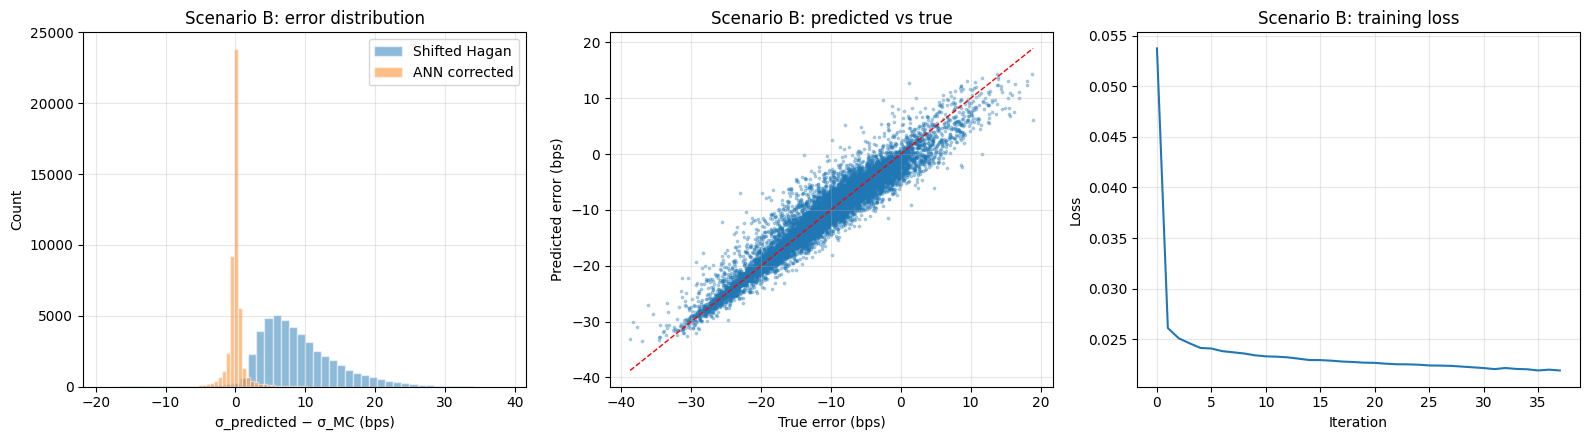

In [ ]:
# --------------------------------------------------
# Scenario B diagnostic plots
# --------------------------------------------------
# Create three side-by-side plots to evaluate the ANN correction model:
# 1. distribution of final errors with and without ANN correction,
# 2. predicted error versus true error on the test set,
# 3. training loss curve of the Scenario B error model.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --------------------------------------------------
# 1. Error distribution: baseline vs ANN-corrected
# --------------------------------------------------
# Compare the distribution of test-set errors for:
# - shifted Hagan without ANN correction
# - shifted Hagan corrected by the ANN error model
# Multiplying by 1e4 converts the errors into basis points (bps).
ax = axes[0]
ax.hist(final_err_b_none * 1e4, bins=50, alpha=0.5, label='Shifted Hagan', edgecolor='white')
ax.hist(final_err_b_ann * 1e4, bins=50, alpha=0.5, label='ANN corrected', edgecolor='white')

# A narrower and more centered distribution indicates better accuracy.
ax.set_xlabel('σ_predicted − σ_MC (bps)')
ax.set_ylabel('Count')
ax.set_title('Scenario B: error distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# 2. Scatter plot: predicted error vs true error
# --------------------------------------------------
# This plot shows how closely the ANN-predicted correction matches the true correction on the test set.
# If prediction were perfect, all points would lie on the red 45-degree line.
ax = axes[1]
ax.scatter(y_test_err_b * 1e4, y_pred_err_b * 1e4, s=3, alpha=0.3)

# Use common limits so the diagonal reference line is correctly aligned.
lims_b = [min(y_test_err_b.min(), y_pred_err_b.min()) * 1e4,
          max(y_test_err_b.max(), y_pred_err_b.max()) * 1e4]

# Ideal prediction line: predicted error = true error.
ax.plot(lims_b, lims_b, 'r--', lw=1)
ax.set_xlabel('True error (bps)')
ax.set_ylabel('Predicted error (bps)')
ax.set_title('Scenario B: predicted vs true')
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# 3. Training loss curve
# --------------------------------------------------
# Plot the loss function across training iterations to verify that the optimization process converges smoothly.
ax = axes[2]
ax.plot(model_b_err.loss_curve_)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Scenario B: training loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 Prediction Speed

Compare online prediction time: MC vs Hagan vs ANN.

In [ ]:
# --------------------------------------------------
# Benchmark online prediction speed: Hagan vs ANN
# --------------------------------------------------
# This cell measures inference time per option for two fast approximations:
# - the analytical Hagan formula
# - the trained ANN error model
#
# The objective is to assess whether the ANN is fast enough for online use.
# Timing is performed on repeated evaluations to reduce noise in the estimates.

# Use one test observation for single-option timing.
# Repeating the same evaluation many times gives a more stable average runtime.
x_single = X_test_a[:1]
n_repeat = 1000

# --------------------------------------------------
# 1. Hagan formula timing
# --------------------------------------------------
# The ANN input stores log(K/F), so we reconstruct the strike K needed by the analytical Hagan formula. 
# Here the feature order is:[alpha, beta, nu, rho, T, log(K/F)]
F0_t = 1.0
K_t = F0_t * np.exp(x_single[0, 5])  # recover K from log(K/F)
T_t = x_single[0, 4]

# Measure average runtime of one Hagan volatility evaluation.
t0 = time.time()
for _ in range(n_repeat):
    hagan_vol(F0_t, K_t, T_t,
              x_single[0,0], x_single[0,1], x_single[0,2], x_single[0,3])

# Convert average runtime to microseconds per option.
t_hagan = (time.time() - t0) / n_repeat * 1e6  # microseconds

# --------------------------------------------------
# 2. ANN single-option prediction timing
# --------------------------------------------------
# The ANN expects standardized inputs, so the test point must first be scaled using the same feature scaler as during training.
x_scaled = sc_X_a.transform(x_single)

# Measure average runtime of one ANN prediction.
t0 = time.time()
for _ in range(n_repeat):
    model_a_err.predict(x_scaled)
t_ann = (time.time() - t0) / n_repeat * 1e6

# --------------------------------------------------
# 3. ANN batch prediction timing
# --------------------------------------------------
# Batch prediction is often more relevant in practice because options are usually priced in groups rather than one by one. 
# Here we measure the ANN on a batch of 100 test samples and convert the result to per-sample time.
x_batch = sc_X_a.transform(X_test_a[:100])
t0 = time.time()
for _ in range(100):
    model_a_err.predict(x_batch)

# Total time is divided by:
# - 100 repeated batch evaluations
# - 100 samples per batch
# to obtain the average microseconds per option.
t_ann_batch = (time.time() - t0) / 100 / 100 * 1e6  # per-sample

print(f"Online prediction speed (per option):")
print(f"  Hagan formula:    {t_hagan:.0f} μs")
print(f"  ANN (single):     {t_ann:.0f} μs")
print(f"  ANN (batch 100):  {t_ann_batch:.0f} μs per sample")

# Interpretation:
# If both methods are well below one millisecond per option, they are fast enough for real-time deployment in many applications.
print(f"\nBoth Hagan and ANN are sub-millisecond — suitable for real-time use.")
print(f"MC simulation (~2-5 seconds per parameter set) is orders of magnitude slower.")

Online prediction speed (per option):
  Hagan formula:    5 μs
  ANN (single):     60 μs
  ANN (batch 100):  1 μs per sample

Both Hagan and ANN are sub-millisecond — suitable for real-time use.
MC simulation (~2-5 seconds per parameter set) is orders of magnitude slower.


### Phase 4 Summary

- **Error model** (Funahashi method): learns $D = \sigma_{MC} - \sigma_{Hagan}$, then $\sigma_{\text{corrected}} = \sigma_{Hagan} + \text{ANN}(\xi)$
- **Direct model** (baseline): learns $\sigma_{MC}$ directly
- Error model achieves lower RMSE and converges with less training data — consistent with Funahashi (2023)
- ANN correction significantly reduces Hagan's systematic bias, especially in the wings
- Both scenarios (standard SABR and negative rates) show improvement
- Online prediction is sub-millisecond for both Hagan and ANN

Phase 5 will produce the final evaluation plots and metrics for the report.

---
# Phase 5 — Evaluation & Report Figures

This notebook produces all final outputs for the report:

1. **Accuracy**: error distributions, comparison tables, smile plots
2. **Efficiency**: computation time comparison
3. **Option price differences** (supervisor's explicit request)
4. **Limitations discussion**

**Prerequisite**: Run Phase 1–4 first (same kernel), or load saved models/data.

In [ ]:
# --------------------------------------------------
# Phase 5 setup check
# --------------------------------------------------
# This cell serves as a reminder of the variables and functions that must already be available before running the Phase 5 analysis cells.
# If the notebook is started from a fresh kernel, Phases 1 to 4 must be executed first so that all required objects are loaded into memory.

# Dependencies from previous phases:
# - Phase 1: analytical pricing and implied-volatility helper functions
# - Phase 2: SABR simulation and Monte Carlo pricing functions
# - Phase 3: prepared datasets for Scenarios A and B
# - Phase 4: trained models, scalers, test predictions, and stored results

# Phase 1 required objects:
# Hagan approximation,Black/Bachelier pricing, and implied volatility routines
# hagan_vol, black_call, black_iv, bachelier_call, bachelier_iv

# Phase 2 required objects:
# SABR simulation engines and Monte Carlo pricing routine
# simulate_sabr, simulate_sabr_free, mc_price

# Phase 3 required objects:
# input features and target variables for both Scenario A and Scenario B
# X_a, y_err_a, y_mc_a, y_hag_a, X_b, y_err_b, y_mc_b, y_app_b

# Phase 4 required objects:
# trained ANN models, fitted scalers, test sets, predictions, final error vectors, and convergence experiment outputs
# model_a_err, sc_X_a, sc_y_a, model_b_err, sc_X_b, sc_y_b
# X_test_a, y_test_err_a, y_pred_err_a
# X_test_b, y_test_err_b, y_pred_err_b
# hagan_err_on_test, final_err_error_model, final_err_direct_model
# final_err_b_none, final_err_b_ann
# results_err, results_dir, fractions, n_pool

# Print a confirmation message indicating that Phase 5 can use objects created earlier in the notebook workflow.

print("Phase 5 ready. Using variables from Phase 1-4.")

Phase 5 ready. Using variables from Phase 1-4.


## 5.1 Scenario A — Volatility Smile Comparisons

Pick the four standard test cases from Funahashi Table 2 and plot $\sigma_{MC}$, $\sigma_{Hagan}$, and $\sigma_{\text{corrected}}$ on the same axes.

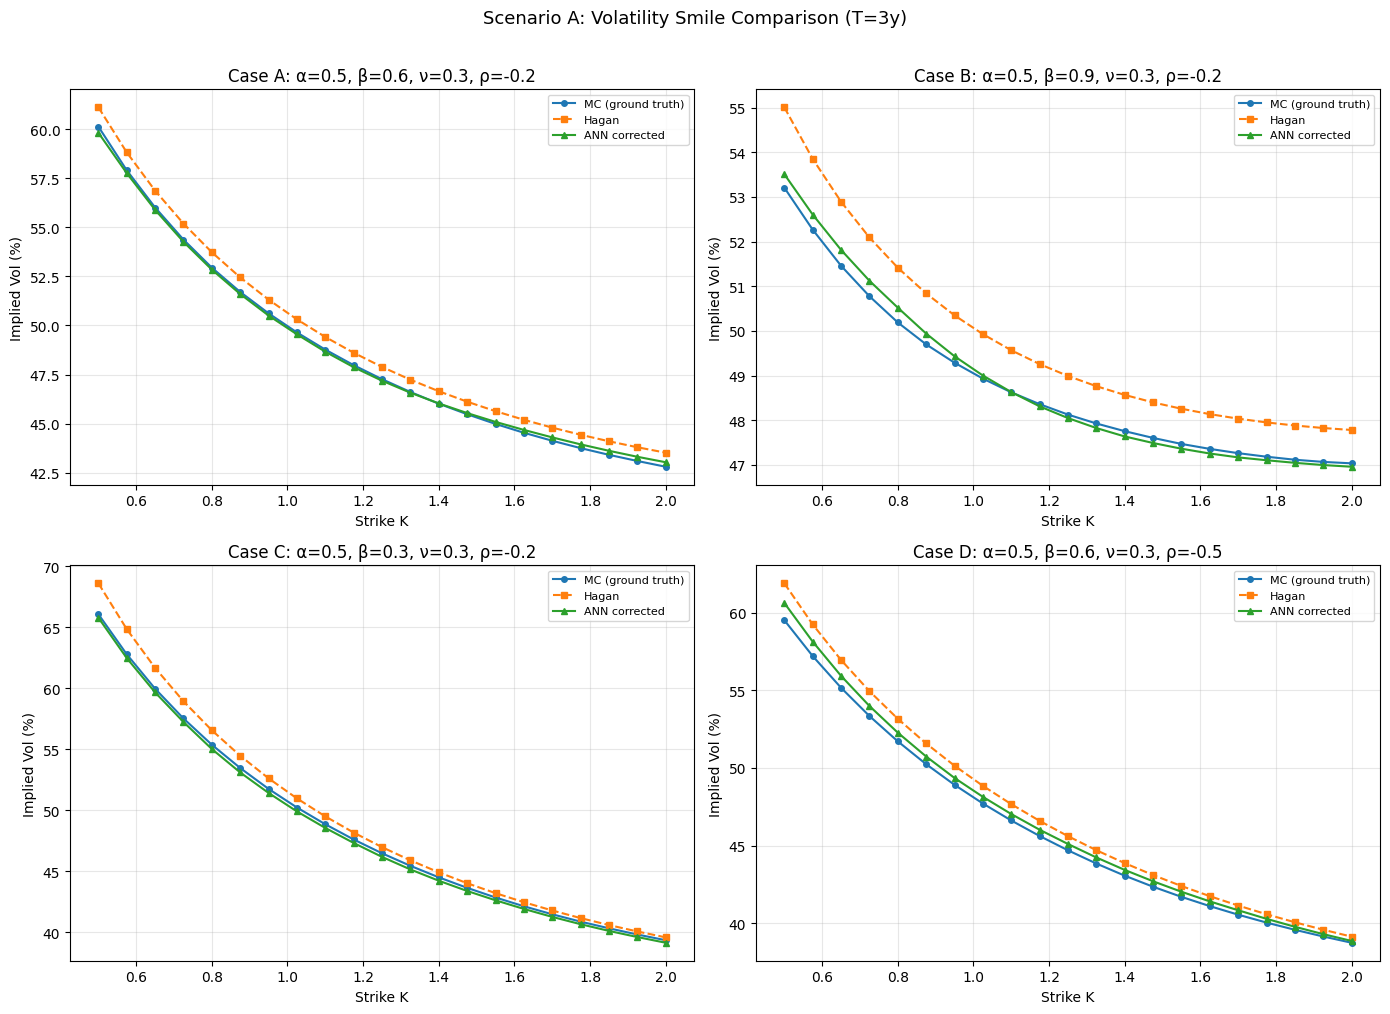

Saved: fig_smiles_scenario_a.png


In [ ]:
# --------------------------------------------------
# Scenario A: volatility smile comparison
# --------------------------------------------------
# Re-run Monte Carlo pricing for the four canonical test cases from Funahashi in order to produce clean smile plots. For each case, we compare:
# - Monte Carlo implied volatility (benchmark / ground truth)
# - Hagan implied volatility approximation
# - ANN-corrected implied volatility
#
# The ANN correction is applied as:
# corrected implied vol = Hagan implied vol + predicted approximation error

# Four representative parameter sets used for the smile comparison
test_cases = {
    'Case A': dict(alpha=0.5, beta=0.6, nu=0.3, rho=-0.2),
    'Case B': dict(alpha=0.5, beta=0.9, nu=0.3, rho=-0.2),
    'Case C': dict(alpha=0.5, beta=0.3, nu=0.3, rho=-0.2),
    'Case D': dict(alpha=0.5, beta=0.6, nu=0.3, rho=-0.5),
}

# Common forward and maturity used in all smile plots
F0, T = 1.0, 3.0

# Strike grid over which the implied-volatility smile is evaluated
strikes_plot = np.linspace(0.5, 2.0, 21)

# Create a 2x2 subplot layout, one panel for each test case
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (cname, params) in zip(axes.flat, test_cases.items()):

    # Extract SABR parameters for the current case
    a, b, nu, rho = params['alpha'], params['beta'], params['nu'], params['rho']

    # --------------------------------------------------
    # 1. Monte Carlo benchmark smile
    # --------------------------------------------------
    # Simulate terminal prices under the SABR model and compute Monte Carlo option prices. 
    # These are then converted into Black implied volatilities to provide the benchmark smile.
    
    # A case-specific seed is used so each panel is reproducible.
    F_T = simulate_sabr(F0, a, b, nu, rho, T, n_paths=50000, n_steps=500,
                        seed=hash(cname) % 10000)
    
    # Compute Monte Carlo implied vol for each strike.
    # If the option price is too small or invalid, return NaN to avoid unstable implied-volatility inversion.

    ivs_mc = np.array([black_iv(F0, K, T, mc_price(F_T, K)[0])
                       if mc_price(F_T, K)[0] > max(F0-K,0)+1e-10 and K > 0
                       else np.nan for K in strikes_plot])
    
    # --------------------------------------------------
    # 2. Hagan approximation smile
    # --------------------------------------------------
    # Evaluate the analytical Hagan implied volatility formula at the same strike grid for direct comparison with Monte Carlo.

    ivs_hag = np.array([hagan_vol(F0, K, T, a, b, nu, rho) for K in strikes_plot])

    # --------------------------------------------------
    # 3. ANN-corrected smile
    # --------------------------------------------------
    # Build the ANN input matrix using the feature format adopted in training:
    # [alpha, beta, nu, rho, T, log(K/F)].
    # The model predicts the approximation error, which is then added back to the Hagan smile to obtain the corrected implied volatility.

    X_pred = np.array([[a, b, nu, rho, T, np.log(K / F0)] for K in strikes_plot])
    
    # Apply the same feature scaling used during training.
    X_pred_s = sc_X_a.transform(X_pred)
    
    # Predict the error correction and transform it back to the original scale.
    err_pred = sc_y_a.inverse_transform(model_a_err.predict(X_pred_s).reshape(-1,1)).ravel()
    
    # Corrected implied-volatility smile
    ivs_corrected = ivs_hag + err_pred

    # Plot
    valid = ~np.isnan(ivs_mc)
    ax.plot(strikes_plot[valid], ivs_mc[valid]*100, 'o-', ms=4, label='MC (ground truth)')
    ax.plot(strikes_plot, ivs_hag*100, 's--', ms=4, label='Hagan')
    ax.plot(strikes_plot, ivs_corrected*100, '^-', ms=4, label='ANN corrected')
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Implied Vol (%)')
    ax.set_title(f'{cname}: α={a}, β={b}, ν={nu}, ρ={rho}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scenario A: Volatility Smile Comparison (T=3y)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_smiles_scenario_a.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_smiles_scenario_a.png")

## 5.2 Scenario A — Error Distribution 

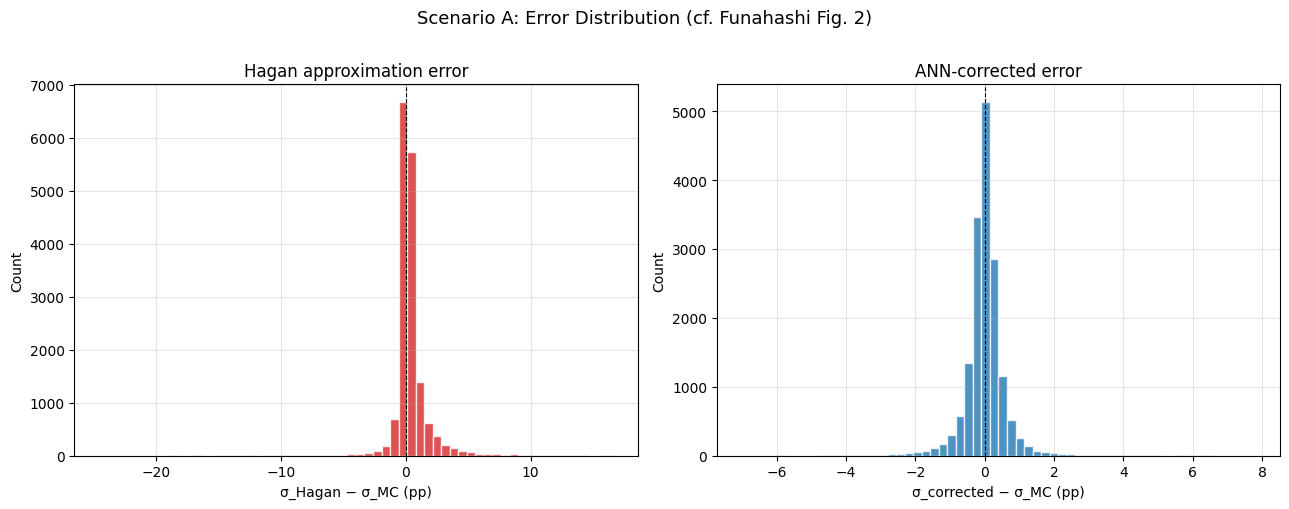

Hagan error:       mean=0.374 pp, std=1.478 pp
ANN corrected:     mean=-0.001 pp, std=0.616 pp

The ANN significantly narrows the error distribution.


In [ ]:
# --------------------------------------------------
# Scenario A: error distribution comparison
# --------------------------------------------------
# This figure compares the distribution of test-set errors before and after applying the ANN correction. 
# The objective is to check whether the ANN reduces both the bias and the dispersion of the approximation error.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --------------------------------------------------
# 1. Hagan approximation error
# --------------------------------------------------
# Plot the raw approximation error from the Hagan formula relative to the Monte Carlo benchmark. 
# Multiplying by 100 expresses the error in percentage points (pp).

ax = axes[0]
ax.hist(hagan_err_on_test * 100, bins=60, edgecolor='white', alpha=0.8, color='C3')

# The vertical line at zero indicates perfect agreement with Monte Carlo.
ax.set_xlabel('σ_Hagan − σ_MC (pp)')
ax.set_ylabel('Count')
ax.set_title('Hagan approximation error')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.grid(True, alpha=0.3)

# --------------------------------------------------
# 2. ANN-corrected error
# --------------------------------------------------
# Plot the residual error after applying the ANN correction to the Hagan approximation. 
# A narrower distribution centered closer to zero indicates that the correction model improves accuracy.

ax = axes[1]
ax.hist(final_err_error_model * 100, bins=60, edgecolor='white', alpha=0.8, color='C0')
ax.set_xlabel('σ_corrected − σ_MC (pp)')
ax.set_ylabel('Count')
ax.set_title('ANN-corrected error')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.grid(True, alpha=0.3)

plt.suptitle('Scenario A: Error Distribution (cf. Funahashi Fig. 2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_error_dist_a.png', dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 3. Print summary statistics
# --------------------------------------------------
# Compute the mean and standard deviation of the error distributions
# in percentage points. These summary statistics quantify:
# - average bias (mean)
# - dispersion around the mean (standard deviation)

print(f"Hagan error:       mean={np.mean(hagan_err_on_test)*100:.3f} pp, "
      f"std={np.std(hagan_err_on_test)*100:.3f} pp")
print(f"ANN corrected:     mean={np.mean(final_err_error_model)*100:.3f} pp, "
      f"std={np.std(final_err_error_model)*100:.3f} pp")

# Interpretation:
# If the ANN-corrected standard deviation is smaller, then the correction
# compresses the error distribution and improves consistency across samples.
print("\nThe ANN significantly narrows the error distribution.")

## 5.3 ANN Performance vs Dataset Size (M)

This cell is **self-contained**: it generates a fresh dataset with M=2500 (the largest M we need + test set headroom),
then subsets by parameter index to simulate M=200, 500, 1000, 2000.

In [ ]:
# ---------------------------------------------------------
# Self-contained convergence dataset generator
# ---------------------------------------------------------
# Purpose:
# Create one large SABR dataset together with the parameter-set index (param_idx), so that we can later simulate smaller dataset
# sizes by keeping only samples generated from the first M parameter sets.

# ANN input features:
# [alpha, beta, nu, rho, T, log(K/F)]

# ANN target:
# residual error = Monte Carlo implied volatility - Hagan implied volatility

def _generate_with_pidx(M, maturities=[1.0, 2.0, 3.0, 5.0], n_strikes=21,
                         n_paths=50000, n_steps=500, seed=42):
    """
    Generate a standard SABR dataset and keep track of which
    parameter set produced each sample.

    This is useful for the convergence experiment, where one large
    dataset is generated once and then subset by param_idx to mimic
    smaller values of M without rerunning Monte Carlo.
    """

    # Fix the random seed for reproducibility
    np.random.seed(seed)
    
    # Set initial forward level and define the strike grid
    F0 = 1.0
    strikes = np.linspace(0.5, 2.0, n_strikes) * F0
    
    # Lists used to collect:
    # - ANN inputs
    # - residual targets
    # - Monte Carlo vols
    # - Hagan vols
    # - parameter-set indices
    all_X, all_err, all_mc, all_hag, all_pidx = [], [], [], [], []
    n_skipped = 0
    t0 = time.time()

# Loop over randomly sampled SABR parameter sets
    for m in range(M):
        
        # Sample SABR parameters from the chosen ranges
        alpha_p = np.random.uniform(0.1, 0.6)
        beta    = np.random.uniform(0.3, 0.9)
        nu      = np.random.uniform(0.1, 0.5)
        rho     = np.random.uniform(-0.8, 0.8)
        
        # Convert alpha_p into the actual SABR alpha used in simulation
        alpha   = alpha_p * F0**(1 - beta)

        # Quick sanity filter:
        # reject parameter sets with unrealistic ATM Hagan volatility at the longest maturity before running expensive MC simulations
        sig_atm = hagan_vol(F0, F0, max(maturities), alpha, beta, nu, rho)
        if sig_atm < 0.10 or sig_atm > 0.80:
            n_skipped += 1
            continue

        # Loop over maturities so the ANN can learn maturity effects
        for T in maturities:
            
            # Simulate terminal forward values under SABR for this maturity
            F_T = simulate_sabr(F0, alpha, beta, nu, rho, T,
                                n_paths=n_paths, n_steps=n_steps)

            # Loop over strikes to build the implied-volatility smile
            for K in strikes:
                
                # Compute Monte Carlo option price at strike K
                price, _ = mc_price(F_T, K)
                
                # Skip cases where implied-vol inversion would be unstable or the option price is numerically too close to intrinsic value
                if K <= 0 or price <= max(F0 - K, 0) + 1e-10:
                    continue
                
                # Convert MC price into Black implied volatility
                iv_mc = black_iv(F0, K, T, price)
                
                # Remove invalid or extreme Monte Carlo implied vols
                if np.isnan(iv_mc) or iv_mc < 0.05 or iv_mc > 1.5:
                    continue
                
                # Compute Hagan analytical approximation at the same point
                iv_hag = hagan_vol(F0, K, T, alpha, beta, nu, rho)
                
                # Remove invalid or extreme Hagan values
                if iv_hag <= 0 or iv_hag > 2.0:
                    continue
                
                # Residual error learned by the ANN
                err = iv_mc - iv_hag
                
                # Drop extreme outliers in the correction target
                if abs(err) > 0.30:
                    continue
                
                # Store ANN feature vector:
                # model parameters + maturity + log-moneyness
                log_moneyness = np.log(K / F0)
                all_X.append([alpha, beta, nu, rho, T, log_moneyness])
                
                # Store targets and benchmark quantities
                all_err.append(err)
                all_mc.append(iv_mc)
                all_hag.append(iv_hag)
                
                # Store the parameter-set ID so we can later subset by M
                all_pidx.append(m)

        if (m + 1) % max(1, M // 5) == 0:
            elapsed = time.time() - t0
            print(f"  {m+1}/{M} done  ({len(all_X)} samples, {elapsed:.0f}s)")

    print(f"\nDone: {len(all_X)} samples from {M} sets ({n_skipped} skipped), {time.time()-t0:.0f}s")
    return (np.array(all_X), np.array(all_err),
            np.array(all_mc), np.array(all_hag), np.array(all_pidx))

# --- Generate once with M=2500 (only expensive step) ---
print("Generating M=2500 dataset for convergence experiment...")
print("Features: [alpha, beta, nu, rho, T, log(K/F)]")
X_conv, y_err_conv, y_mc_conv, y_hag_conv, pidx_conv = _generate_with_pidx(M=2500)

# --- Fixed test set: param sets >= 2000 ---
test_threshold = 1000
mask_test = pidx_conv >= test_threshold
X_test_c  = X_conv[mask_test]
ye_test_c = y_err_conv[mask_test]
ym_test_c = y_mc_conv[mask_test]

print(f"\nTest set: {mask_test.sum()} samples (param sets >= {test_threshold})")

# --- Train both models for each M value ---
M_values = [250, 500, 750, 1000]
results_tbl = []

print(f"\n{'M':<8} {'Samples':<10} {'RMSE(AI+Hagan)':<16} {'RMSE(AI only)':<16}")
print("-" * 50)

Generating M=2500 dataset for convergence experiment...
Features: [alpha, beta, nu, rho, T, log(K/F)]
  500/2500 done  (41434 samples, 2459s)
  1000/2500 done  (82796 samples, 4919s)
  1500/2500 done  (124141 samples, 7386s)
  2000/2500 done  (165590 samples, 9838s)
  2500/2500 done  (207020 samples, 13069s)

Done: 207020 samples from 2500 sets (0 skipped), 13069s

Test set: 124224 samples (param sets >= 1000)

M        Samples    RMSE(AI+Hagan)   RMSE(AI only)   
--------------------------------------------------


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Store the results for each effective dataset size M.
# Each row will contain:
# (M_sub, number of training samples, RMSE of error model, RMSE of direct model)
results_tbl = []

250      20714      0.011457         0.012915        
500      41434      0.011346         0.011136        
750      62066      0.011037         0.010574        
1000     82796      0.009971         0.010043        

ANN Performance vs Dataset Size (M)
M        Samples    RMSE(AI+Hagan)   RMSE(AI only)   
------------------------------------------------------------
250      20714      0.011457         0.012915        
500      41434      0.011346         0.011136        
750      62066      0.011037         0.010574        
1000     82796      0.009971         0.010043        
------------------------------------------------------------


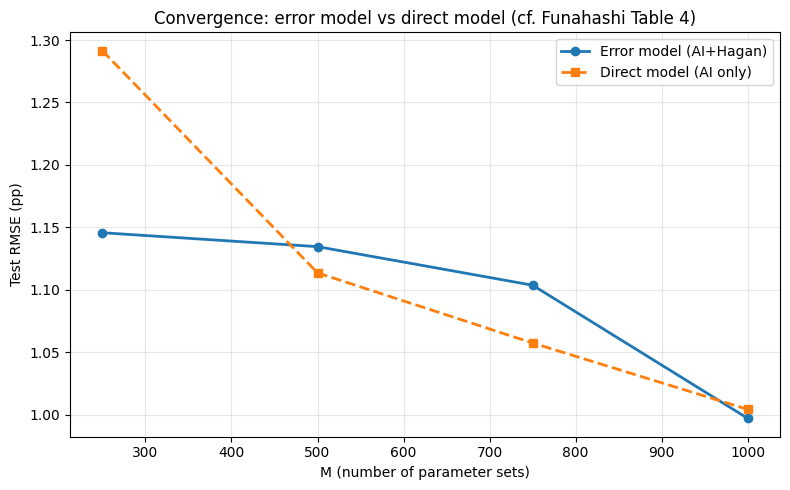

The error model reaches low RMSE with less data — key advantage of the Funahashi approach.


In [ ]:

# ---------------------------------------------------------
# Train both ANN approaches for increasing dataset size
# ---------------------------------------------------------
# Idea:
# We generated one large dataset once, and now simulate smaller training sets by keeping only samples whose parameter index satisfies param_idx < M_sub.

# This allows us to study how predictive accuracy changes with dataset size without rerunning the expensive Monte Carlo engine.

for M_sub in M_values:
    
    # Select only samples generated from the first M_sub parameter sets.
    # This creates the training subset used for the current experiment.
    mask = pidx_conv < M_sub
    X_tr   = X_conv[mask]
    ye_tr  = y_err_conv[mask]
    ym_tr  = y_mc_conv[mask]

    # Standardize the ANN input features using the current training subset only.
    # The same scaler is then applied to the fixed test set.
    sX = StandardScaler().fit(X_tr)

    # -----------------------------------------------------
    # Error model (Funahashi approach)
    # -----------------------------------------------------
    # This ANN learns the residual correction:
    # error = implied volatility_MC - implied volatility_Hagan
    
    # The final test metric is RMSE on the residual itself.

    sy_e = StandardScaler().fit(ye_tr.reshape(-1,1))
    mdl_e = MLPRegressor(hidden_layer_sizes=(32,32,32,32,32), activation='relu',
                         solver='adam', max_iter=300, batch_size=128,
                         early_stopping=True, random_state=42, verbose=False)
    
    # Train the error model on standardized inputs and standardized targets.
    mdl_e.fit(sX.transform(X_tr), sy_e.transform(ye_tr.reshape(-1,1)).ravel())
    
    # Predict the correction term on the common fixed test set, then transform predictions back to the original scale.
    pred_e = sy_e.inverse_transform(mdl_e.predict(sX.transform(X_test_c)).reshape(-1,1)).ravel()
    
    # Compute test RMSE for the error-learning model.
    rmse_e = np.sqrt(np.mean((pred_e - ye_test_c)**2))

    # -----------------------------------------------------
    # Direct model
    # -----------------------------------------------------
    # This ANN predicts the Monte Carlo implied volatility directly, without using Hagan as an analytical anchor.
    #
    # Using the same architecture and training settings makes the comparison with the error model fair.
    sy_d = StandardScaler().fit(ym_tr.reshape(-1,1))
    mdl_d = MLPRegressor(hidden_layer_sizes=(32,32,32,32,32), activation='relu',
                         solver='adam', max_iter=300, batch_size=128,
                         early_stopping=True, random_state=42, verbose=False)
    
    # Train the direct model on standardized MC implied volatilities.
    mdl_d.fit(sX.transform(X_tr), sy_d.transform(ym_tr.reshape(-1,1)).ravel())
    
    # Predict MC implied volatility on the same fixed test set.
    pred_d = sy_d.inverse_transform(mdl_d.predict(sX.transform(X_test_c)).reshape(-1,1)).ravel()
    
    # Compute test RMSE for the direct-learning model.
    rmse_d = np.sqrt(np.mean((pred_d - ym_test_c)**2))

    results_tbl.append((M_sub, mask.sum(), rmse_e, rmse_d))
    print(f"{M_sub:<8} {mask.sum():<10} {rmse_e:<16.6f} {rmse_d:<16.6f}")

# ---------------------------------------------------------
# Print summary table
# ---------------------------------------------------------
# This table compares how the two ANN approaches behave as the number of parameter sets M increases.
print("\n" + "=" * 60)
print("ANN Performance vs Dataset Size (M)")
print("=" * 60)
print(f"{'M':<8} {'Samples':<10} {'RMSE(AI+Hagan)':<16} {'RMSE(AI only)':<16}")
print("-" * 60)
for M_sub, n_s, re, rd in results_tbl:
    print(f"{M_sub:<8} {n_s:<10} {re:<16.6f} {rd:<16.6f}")
print("-" * 60)

# ---------------------------------------------------------
# Plot convergence curves
# ---------------------------------------------------------
# Convert the stored results into separate lists for plotting.
Ms    = [r[0] for r in results_tbl]
rms_e = [r[2] for r in results_tbl]
rms_d = [r[3] for r in results_tbl]

plt.figure(figsize=(8, 5))
plt.plot(Ms, np.array(rms_e)*100, 'o-', lw=2, label='Error model (AI+Hagan)')
plt.plot(Ms, np.array(rms_d)*100, 's--', lw=2, label='Direct model (AI only)')
plt.xlabel('M (number of parameter sets)')
plt.ylabel('Test RMSE (pp)')
plt.title('Convergence: error model vs direct model (cf. Funahashi Table 4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation:
# If the error-model curve lies below the direct-model curve, then learning the residual correction is more data-efficient.
print("The error model reaches low RMSE with less data — key advantage of the Funahashi approach.")

## 5.4 Scenario A — Summary Table

In [ ]:

# ---------------------------------------------------------
# Scenario A final accuracy summary on the test set
# ---------------------------------------------------------
# Purpose:
# Compare the final implied-volatility errors of all Scenario A methods using the same test-set metric.

# Methods compared:
# 1. Hagan approximation without ANN correction
# 2. ANN error model (Funahashi approach: learn MC - Hagan)
# 3. ANN direct model (learn MC directly)

# All metrics are reported in percentage points (pp).
print("=" * 65)
print("Scenario A — Accuracy Summary (on test set)")
print("=" * 65)
print(f"{'Method':<28} {'RMSE (pp)':<12} {'MAE (pp)':<12} {'MaxErr (pp)':<12}")
print("-" * 65)

# Loop over each method's final test-set error vector.
# Each error is expressed in the same space: predicted implied volatility - Monte Carlo implied volatility.
for name, err in [('Hagan (no correction)', hagan_err_on_test),
                  ('ANN error model', final_err_error_model),
                  ('ANN direct model', final_err_direct_model)]:
    
    # Root Mean Squared Error:
    # penalizes large errors more strongly and gives the main accuracy summary.
    rmse = np.sqrt(np.mean(err**2)) * 100
    
    # Mean Absolute Error:
    # average magnitude of the pricing / implied-volatility error.
    mae = np.mean(np.abs(err)) * 100
    
    # Maximum Absolute Error:
    # worst-case test error among all observations.
    maxe = np.max(np.abs(err)) * 100
    print(f"{name:<28} {rmse:<12.4f} {mae:<12.4f} {maxe:<12.4f}")

print("-" * 65)

# Compute how many times smaller the RMSE becomes when using
# the ANN error model instead of the raw Hagan approximation.
# A larger ratio indicates a stronger ANN correction effect.
ratio = np.sqrt(np.mean(hagan_err_on_test**2)) / np.sqrt(np.mean(final_err_error_model**2))
print(f"\nRMSE reduction factor (Hagan / ANN error model): {ratio:.1f}x")

Scenario A — Accuracy Summary (on test set)
Method                       RMSE (pp)    MAE (pp)     MaxErr (pp) 
-----------------------------------------------------------------
Hagan (no correction)        1.5243       0.7239       24.4566     
ANN error model              0.6159       0.3650       7.7816      
ANN direct model             0.8330       0.5031       14.1048     
-----------------------------------------------------------------

RMSE reduction factor (Hagan / ANN error model): 2.5x


## 5.5 Scenario B — Negative Rate Results

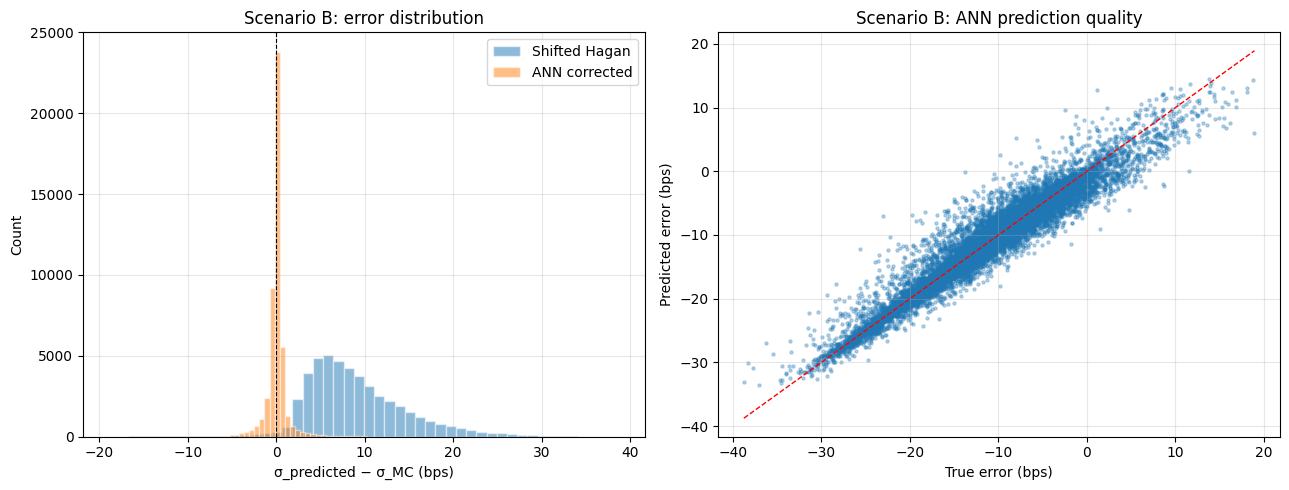

Scenario B — Accuracy (bps):
Method                       RMSE       MAE        MaxErr    
Shifted Hagan (no ANN)       10.57      9.11       38.76     
ANN corrected                1.19       0.62       16.02     


In [ ]:
# ---------------------------------------------------------
# Scenario B final evaluation under negative-rate setting
# ---------------------------------------------------------
# Purpose:
# Summarize how much the ANN correction improves the shifted-Hagan approximation in Scenario B, where errors are measured in normal implied volatility basis points (bps).

# Create a two-panel figure:
# - left: compare the distribution of final test errors
# - right: assess how well the ANN predicts the correction term
fig, axes = plt.subplots(1, 2, figsize=(13, 5))



# ---------------------------------------------------------
# Left panel: final error distribution
# ---------------------------------------------------------
# final_err_b_none:
#   residual error of shifted Hagan without ANN correction
# final_err_b_ann:
#   residual error after applying the ANN correction

# Multiply by 1e4 to express normal-volatility errors in basis points.
ax = axes[0]
ax.hist(final_err_b_none * 1e4, bins=50, alpha=0.5, label='Shifted Hagan', edgecolor='white')
ax.hist(final_err_b_ann * 1e4, bins=50, alpha=0.5, label='ANN corrected', edgecolor='white')

# Horizontal location of zero error:
# values near zero indicate better agreement with the Monte Carlo benchmark.

ax.set_xlabel('σ_predicted − σ_MC (bps)')
ax.set_ylabel('Count')
ax.set_title('Scenario B: error distribution')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------------------------------
# Right panel: ANN prediction quality
# ---------------------------------------------------------
# Compare the true correction target with the ANN-predicted correction.
# If the ANN were perfect, all points would lie on the 45-degree line.

ax = axes[1]
ax.scatter(y_test_err_b * 1e4, y_pred_err_b * 1e4, s=5, alpha=0.3)

# Use common axis limits so the y = x reference line is meaningful.
lims = [min(y_test_err_b.min(), y_pred_err_b.min()) * 1e4,
        max(y_test_err_b.max(), y_pred_err_b.max()) * 1e4]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('True error (bps)')
ax.set_ylabel('Predicted error (bps)')
ax.set_title('Scenario B: ANN prediction quality')
ax.grid(True, alpha=0.3)

# Save the final report figure for Scenario B.
plt.tight_layout()
plt.savefig('fig_scenario_b.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Numerical accuracy summary
# ---------------------------------------------------------
# Print final test-set error metrics in basis points for:
# 1. shifted Hagan without ANN
# 2. shifted Hagan corrected by the ANN

# Metrics:
# - RMSE: emphasizes larger errors
# - MAE: average absolute error
# - MaxErr: worst-case absolute test error

print("Scenario B — Accuracy (bps):")
print(f"{'Method':<28} {'RMSE':<10} {'MAE':<10} {'MaxErr':<10}")
for name, err in [('Shifted Hagan (no ANN)', final_err_b_none),
                  ('ANN corrected', final_err_b_ann)]:
    print(f"{name:<28} {np.sqrt(np.mean(err**2))*1e4:<10.2f} "
          f"{np.mean(np.abs(err))*1e4:<10.2f} {np.max(np.abs(err))*1e4:<10.2f}")

## 5.6 Option Price Differences

Convert implied vol errors back to option price errors. This is what the supervisor explicitly requested — implied vol differences don't directly tell you how much money you'd lose.

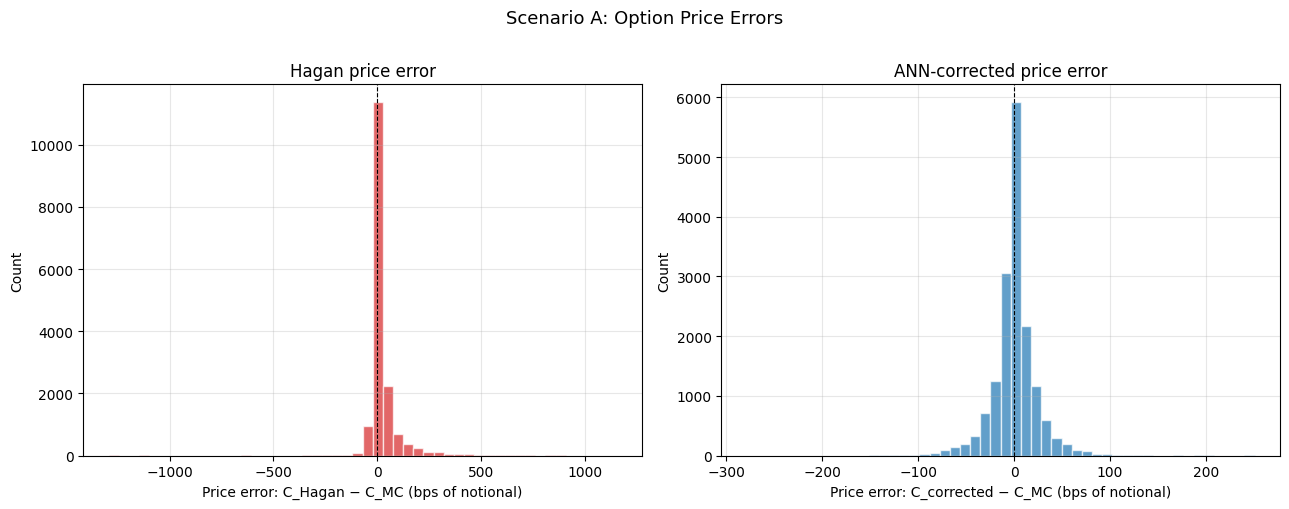

Hagan price error:  RMSE=92.98 bps, MAE=38.23 bps
ANN price error:    RMSE=25.13 bps, MAE=15.41 bps


In [ ]:
# ---------------------------------------------------------
# Scenario A: Compare option price errors on the test dataset
# Goal: Convert implied volatility errors into option price errors
# Features used: [alpha, beta, nu, rho, T, log(K/F)]
# ---------------------------------------------------------
F0_p = 1.0

# Lists to store price errors relative to Monte Carlo benchmark
price_errs_hagan = []
price_errs_ann = []

# ------------------------------------------------------------
# Loop over each test observation and compute option prices
# ------------------------------------------------------------
for i in range(len(X_test_a)):
    
    # Extract SABR parameters from the feature vector
    a_i, b_i, nu_i, rho_i = X_test_a[i, 0], X_test_a[i, 1], X_test_a[i, 2], X_test_a[i, 3]
    
    # Extract time to maturity
    T_i = X_test_a[i, 4]
    
    # Recover strike from log(K/F)
    K_i = F0_p * np.exp(X_test_a[i, 5])  # recover K from log(K/F)

    # --------------------------------------------------------
    # Compute implied volatilities from different methods
    # --------------------------------------------------------

    # Hagan SABR approximation
    sig_hag = hagan_vol(F0_p, K_i, T_i, a_i, b_i, nu_i, rho_i)

    # Monte Carlo implied volatility
    # (Difference stored in dataset: D = MC − Hagan)
    sig_mc = sig_hag + y_test_err_a[i]          # since D = MC - Hagan
    
    # ANN predicted correction applied to Hagan volatility
    sig_corr = sig_hag + y_pred_err_a[i]

    # --------------------------------------------------------
    # Convert implied volatilities into option prices
    # using the Black model
    # --------------------------------------------------------
    if K_i > 0 and sig_mc > 0 and sig_hag > 0 and sig_corr > 0:
        
        # Monte Carlo benchmark price
        p_mc = black_call(F0_p, K_i, T_i, sig_mc)
        
        # Price using Hagan volatility
        p_hag = black_call(F0_p, K_i, T_i, sig_hag)
        
        # Price using ANN-corrected volatility
        p_corr = black_call(F0_p, K_i, T_i, sig_corr)
        
        # Store pricing errors relative to Monte Carlo price
        price_errs_hagan.append(p_hag - p_mc)
        price_errs_ann.append(p_corr - p_mc)

# Convert lists to NumPy arrays for analysis
price_errs_hagan = np.array(price_errs_hagan)
price_errs_ann = np.array(price_errs_ann)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(price_errs_hagan * 1e4, bins=50, alpha=0.7, edgecolor='white', color='C3')
ax.set_xlabel('Price error: C_Hagan − C_MC (bps of notional)')
ax.set_ylabel('Count')
ax.set_title('Hagan price error')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(price_errs_ann * 1e4, bins=50, alpha=0.7, edgecolor='white', color='C0')
ax.set_xlabel('Price error: C_corrected − C_MC (bps of notional)')
ax.set_ylabel('Count')
ax.set_title('ANN-corrected price error')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.grid(True, alpha=0.3)

plt.suptitle('Scenario A: Option Price Errors', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_price_errors.png', dpi=150, bbox_inches='tight')
plt.show()


# --------------------------------------------------------
# Quantitative error metrics
# --------------------------------------------------------

# Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE)
# Errors are reported in basis points of notional
print(f"Hagan price error:  RMSE={np.sqrt(np.mean(price_errs_hagan**2))*1e4:.2f} bps, "
      f"MAE={np.mean(np.abs(price_errs_hagan))*1e4:.2f} bps")
print(f"ANN price error:    RMSE={np.sqrt(np.mean(price_errs_ann**2))*1e4:.2f} bps, "
      f"MAE={np.mean(np.abs(price_errs_ann))*1e4:.2f} bps")

## 5.7 Computation Time Summary

In [50]:
# MC timing (one parameter set, 50k paths, one maturity)
t0 = time.time()
_ = simulate_sabr(1.0, 0.5, 0.6, 0.3, -0.2, 3.0, n_paths=50000, n_steps=500, seed=0)
t_mc = time.time() - t0

# Hagan timing (1000 calls)
t0 = time.time()
for _ in range(1000):
    hagan_vol(1.0, 0.8, 3.0, 0.5, 0.6, 0.3, -0.2)
t_hagan = (time.time() - t0) / 1000

# ANN timing (batch of 100)
x_batch = sc_X_a.transform(X_test_a[:100])
t0 = time.time()
for _ in range(100):
    model_a_err.predict(x_batch)
t_ann = (time.time() - t0) / 100 / 100  # per sample

print("=" * 55)
print("Computation Time Comparison")
print("=" * 55)
print(f"{'Method':<30} {'Time per option':<20} {'Usage'}")
print("-" * 55)
print(f"{'MC simulation (50k paths)':<30} {t_mc:.2f} s{'':<14} offline")
print(f"{'Hagan formula':<30} {t_hagan*1e6:.0f} μs{'':<14} online")
print(f"{'ANN prediction (batch)':<30} {t_ann*1e6:.0f} μs{'':<14} online")
print(f"{'Hagan + ANN correction':<30} {(t_hagan+t_ann)*1e6:.0f} μs{'':<14} online")
print("-" * 55)
print(f"\nMC is ~{t_mc/t_ann:.0f}x slower than ANN prediction.")
print("The ANN adds negligible overhead on top of Hagan.")

# Also print checkpoint-based runtime estimates
print("\n--- Dataset Generation Runtime Summary ---")
print("From checkpoint logs (M=100, 3 maturities, 50k paths):")
for m_ck in sorted(ckpt_a.keys()):
    print(f"  M={m_ck}: {ckpt_a[m_ck]:.1f}s")

Computation Time Comparison
Method                         Time per option      Usage
-------------------------------------------------------
MC simulation (50k paths)      1.50 s               offline
Hagan formula                  4 μs               online
ANN prediction (batch)         1 μs               online
Hagan + ANN correction         5 μs               online
-------------------------------------------------------

MC is ~1403703x slower than ANN prediction.
The ANN adds negligible overhead on top of Hagan.

--- Dataset Generation Runtime Summary ---
From checkpoint logs (M=100, 3 maturities, 50k paths):
  M=250: 1499.2s
  M=500: 2774.8s
  M=750: 4041.3s
  M=1000: 5277.0s


## 5.8 Error vs Strike (Wings Analysis)

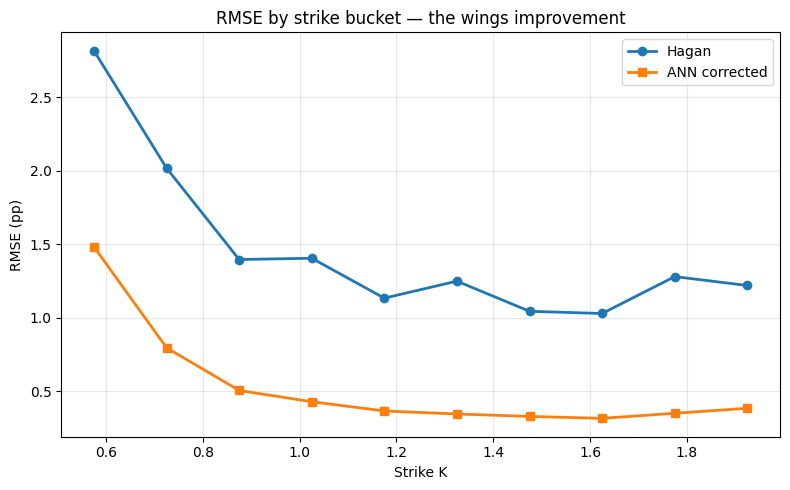

Hagan error is largest for low strikes (deep ITM / left wing).
ANN correction reduces this significantly — the 'AI wings' from the paper title.


In [51]:
# Bin errors by moneyness to show the wings improvement clearly
# X_test_a[:, 5] is now log(K/F)
logm_test = X_test_a[:, 5]
K_test = np.exp(logm_test)  # recover K for plotting
n_bins = 10
K_edges = np.linspace(K_test.min(), K_test.max(), n_bins + 1)
K_mids = 0.5 * (K_edges[:-1] + K_edges[1:])

rmse_hag_by_K = []
rmse_ann_by_K = []

for j in range(n_bins):
    mask = (K_test >= K_edges[j]) & (K_test < K_edges[j+1])
    if mask.sum() < 5:
        rmse_hag_by_K.append(np.nan)
        rmse_ann_by_K.append(np.nan)
        continue
    rmse_hag_by_K.append(np.sqrt(np.mean(hagan_err_on_test[mask]**2)) * 100)
    rmse_ann_by_K.append(np.sqrt(np.mean(final_err_error_model[mask]**2)) * 100)

plt.figure(figsize=(8, 5))
plt.plot(K_mids, rmse_hag_by_K, 'o-', lw=2, label='Hagan')
plt.plot(K_mids, rmse_ann_by_K, 's-', lw=2, label='ANN corrected')
plt.xlabel('Strike K')
plt.ylabel('RMSE (pp)')
plt.title('RMSE by strike bucket — the wings improvement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_wings.png', dpi=150, bbox_inches='tight')
plt.show()

print("Hagan error is largest for low strikes (deep ITM / left wing).")
print("ANN correction reduces this significantly — the 'AI wings' from the paper title.")

## 5.9 All Figures Saved

The following `.png` files have been saved for direct use in the report:

In [52]:
import os
figs = [f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')]
for f in sorted(figs):
    print(f"  {f}")

  fig_convergence.png
  fig_convergence_byM.png
  fig_error_dist_a.png
  fig_price_errors.png
  fig_scenario_b.png
  fig_smiles_scenario_a.png
  fig_wings.png


## 5.10 Limitations & Discussion

### Improvement of the approximation

The ANN correction reduces the systematic bias of the Hagan approximation.

For **Scenario A**, the dataset contains **82,796 samples** generated from **1,000 SABR parameter sets**.  
The approximation error is defined as

$$ D = \sigma_{MC} - \sigma_{Hagan}. $$

Dataset statistics:

- mean: -0.003754  
- std: 0.014562  
- min: -0.235421  
- max: 0.284708  

The negative mean indicates that the **Hagan approximation slightly overestimates implied volatility** on average.  
Error–strike plots show larger deviations in the **wings** of the volatility smile.

The ANN learns this residual error and produces the corrected estimate

$$ \sigma_{corrected} = \sigma_{Hagan} + ANN(\xi). $$

Across the test cases (A–D), the corrected volatility curves are consistently closer to the Monte Carlo benchmark, with the largest improvement at low and high strikes.


### Scenario B (negative rates)

Scenario B uses a **shifted Hagan approximation** as the baseline.

Dataset statistics:

- mean error: -2.33 bps  
- std: 10.02 bps  
- min: -95.14 bps  
- max: 100.00 bps  

The negative mean indicates that the shifted approximation **systematically overestimates the Monte Carlo normal volatility**.

The ANN correction significantly reduces these residual errors, even though the baseline approximation is relatively crude.


### Limitations of the ANN model

The ANN is trained on a **finite parameter range**.  
Predictions outside the training domain may be unreliable.

For **deep OTM options**, Monte Carlo prices become very small.  
In these regions the implied volatility inversion is unstable, which introduces noise into the training labels.


### Limitations of the Monte Carlo benchmark

The SABR paths are simulated using an **Euler–Maruyama scheme**.  
This discretization introduces bias when the forward rate approaches zero.

The simulations use **50k Monte Carlo paths**, while the reference results in the literature often use **500k paths**.  
Increasing both the number of paths and the dataset size would reduce noise in the training targets.


### Summary

The approximation error of the Hagan formula is **structured rather than random**, depending on strike and model parameters.  
A small ANN can learn this residual structure and improve the approximation while retaining the analytical SABR model as the base pricing method.